# Objectif

Identifier les véhicules qui émettent le plus de CO2 est important pour identifier les caractéristiques techniques qui jouent un rôle dans la pollution. Prédire à l’avance cette pollution permet de prévenir dans le cas de l’apparition de nouveaux types de véhicules (nouvelles séries de voitures par exemple).

# Analyse et Nettoyage du dataset UE

Seuls les véhicules des années 2022-2023 et de la France ont été exportés à partir de https://www.eea.europa.eu/data-and-maps/data/co2-cars-emission-20

# <font color='#3585CD'>Importation des librairies</font>

In [1]:
import warnings
warnings.filterwarnings('ignore')
warnings.warn('DelftStack')
warnings.warn('Do not show this message')

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

import plotly.figure_factory as ff
import plotly.express as px
import plotly.graph_objects as go

import kagglehub

from scipy.stats import gaussian_kde

import sys
import os

# <font color='#3585CD'>Fonctions qui seront utilisées dans ce notebook</font>

In [2]:
 # variable de visualisation : 
# si visualisation == plotly alors les graphiques seront intéractifs
# si visualisation == seaborn alors les graphiques seront statiques
visualisation = 'seaborn'

def display_missing_values(df):
  """
  Affiche un DataFrame contenant les valeurs manquantes, leur pourcentage / nombre et leur type, pour chaque colonne du DataFrame.

  :param df: DataFrame contenant la variable à analyser.
  """
  missing_values = df.isnull().sum()
  missing_ratio = (missing_values / len(df)) * 100

  missing_values_df = pd.DataFrame({
      'Colonne': missing_values.index,
      'Valeurs manquantes (%)': missing_ratio.values,
      'Nombre de valeurs manquantes': missing_values.values,
      'Type': df.dtypes.values
  })

  missing_values_df = missing_values_df[missing_values_df['Nombre de valeurs manquantes'] > 0]
  missing_values_df = missing_values_df.sort_values(by='Valeurs manquantes (%)', ascending=False).reset_index(drop=True)

  return missing_values_df

def calculer_correlation(df, col1, col2):
  """
  Calcule et affiche la corrélation entre deux colonnes d'un DataFrame.

  Paramètres :
  df :DataFrame contenant les données.
  col1 : nom de la première colonne.
  col2 : nom de la deuxième colonne.

  Retourne la valeur de la corrélation et une interprétation de son intensité.
  """
  correlation = df[col1].corr(df[col2])
  print(f"Corrélation entre {col1} et {col2} : {correlation:.2f}")

  if abs(correlation) > 0.8:
      interpretation = "Très forte corrélation"
  elif abs(correlation) > 0.6:
      interpretation = "Forte corrélation"
  elif abs(correlation) > 0.4:
      interpretation = "Corrélation modérée"
  elif abs(correlation) > 0.15:
      interpretation = "Corrélation faible"
  else:
      interpretation = "Pas de corrélation linéaire significative"

  print(interpretation + ".\n")

  return correlation, interpretation

def analyse_columns(df):

    """
    Analyse les colonnes d'un DataFrame : nom, type, nombre de valeurs uniques et exemples de valeurs.

    :param df: DataFrame Pandas
    
    Retourne un DataFrame avec l'analyse des colonnes
    """
    analysis = []

    for col in df.columns:
        col_name = col
        col_type = df[col].dtype
        unique_count = df[col].nunique()  # Nombre de valeurs uniques
        unique_values = df[col].dropna().unique()[:5].tolist()  # Exemples (max 5)
        unique_values = " | ".join(map(str, unique_values))  # Séparateur : " | "

        analysis.append({
            'Nom de la colonne': col_name,
            'Type de la colonne': col_type,
            'Nombre de valeurs uniques': unique_count,
            'Exemples de valeurs': unique_values
        })

    return pd.DataFrame(analysis)

def analyser_variable_categorielle(df, variable, top_n=100, display_array=True, viz=visualisation):
    """
    Analyse une variable catégorielle en affichant un DataFrame des 'top_n' catégories les plus fréquentes,
    ainsi qu'un graphique Plotly ou Seaborn.

    :param df: DataFrame contenant la variable à analyser.
    :param variable: Nom de la variable catégorielle.
    :param top_n: Nombre de catégories à afficher (par défaut 100).
    :param display_array: Booléen pour afficher le tableau résumé.
    :param viz: 'plotly' ou 'seaborn'.
    """
    if display_array:
        top_cat = f"(Top {top_n} catégories)" if top_n != 100 else ""
        print(f"\nAnalyse de la variable : {variable} {top_cat}")

    # Calcul des fréquences et pourcentages
    category_counts = df[variable].value_counts().head(top_n)
    category_percent = df[variable].value_counts(normalize=True).head(top_n) * 100

    # Création du DataFrame de synthèse
    df_summary = pd.DataFrame({
        "Libellé": category_counts.index,
        "Total": category_counts.values,
        "Pourcentage": category_percent.values
    })

    # Affichage du tableau
    if display_array:
        display(df_summary)

    # Affichage du graphique
    if viz == 'plotly':
        nb = top_n if top_n != 100 else ""
        fig = px.bar(df_summary,
                     x="Libellé",
                     y="Total",
                     text="Total",
                     title=f'Distribution des {nb} premières catégories de {variable}',
                     labels={"Libellé": variable, "Total": "Nombre d\'occurrences"},
                     template="plotly_white")
        fig.update_traces(textposition='outside')
        fig.update_layout(xaxis_tickangle=-45)
        fig.show()

    elif viz == 'seaborn':
        plt.figure(figsize=(10, 6))
        sns.barplot(data=df_summary, x="Libellé", y="Total", palette="viridis")
        plt.title(f'Distribution des {top_n} premières catégories de {variable}')
        plt.xlabel(variable)
        plt.ylabel("Nombre d'occurrences")
        plt.xticks(rotation=45, ha='right')
        # for index, value in enumerate(df_summary["Total"]):
        #     plt.text(index, value, str(value), ha='center', va='bottom')
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("Le paramètre 'viz' doit être 'plotly' ou 'seaborn'.")

def analyser_variables_numeriques(df, variables, bins=30, viz=visualisation):
    """
    Analyse les variables numériques en affichant un histogramme + KDE (distribution) et un boxplot interactifs.

    :param df: DataFrame contenant les données.
    :param variables: Liste des variables numériques à analyser.
    :param bins: Nombre de bins pour l'histogramme (par défaut 30).
    :param viz: 'plotly' ou 'seaborn'.
    """
    for var in variables:
        data = df[var].dropna()

        if viz == "plotly":
            hist = go.Histogram(
                x=data,
                nbinsx=bins,
                marker=dict(color='skyblue', line=dict(color='black', width=1)),
                opacity=0.6,
                name="Histogramme"
            )

            kde = gaussian_kde(data)
            x_vals = np.linspace(data.min(), data.max(), 500)
            kde_vals = kde(x_vals)

            kde_curve = go.Scatter(
                x=x_vals,
                y=kde_vals * len(data) * (data.max() - data.min()) / bins,
                mode='lines',
                line=dict(color='blue', width=2),
                name="Densité (KDE)"
            )

            fig = go.Figure(data=[hist, kde_curve])
            fig.update_layout(
                title=f'Distribution de {var} (Histogramme + KDE)',
                xaxis_title="Valeur",
                yaxis_title="Fréquence",
                template="plotly_white",
                barmode='overlay'
            )
            fig.show()

        elif viz == "seaborn":
            plt.figure(figsize=(12,6))
            sns.histplot(data, bins=bins, kde=True, color='skyblue', edgecolor='black')
            plt.title(f'Distribution de {var} (Histogramme + KDE)')
            plt.xlabel("Valeur")
            plt.ylabel("Fréquence")
            plt.tight_layout()
            plt.show()

        else:
            raise ValueError("Le paramètre 'viz' doit être 'plotly' ou 'seaborn'.")


def analyser_hist_co2_par_variable(df, variable, top_n=50, order='desc', co2="CO2", viz=visualisation):
    """
    Génère un histogramme avec une ligne de moyenne CO2.

    Paramètres :
    :param df : DataFrame contenant les données
    :param variable : Nom de la colonne à analyser
    :param top_n: Nombre de catégories à afficher (par défaut 50).
    :param order: Ordonnancement des catégories (par défaut 'desc').
    :param co2: Nom de la colonne des émissions de CO2 (par défaut "CO2")
    :param viz: 'plotly' ou 'seaborn'.
    """

    ascending = True if order == 'asc' else False

    df_co2 = df.groupby(variable)[co2].mean().sort_values(ascending=ascending).reset_index()
    df_co2 = df_co2.head(top_n)

    df_co2['CO2_txt'] = df_co2[co2].apply(lambda x: f"{x:.2f}")
    moyenne_co2 = df[co2].mean()

    if viz == 'plotly':
        fig = px.bar(
            df_co2,
            x=variable,
            y=co2,
            title=f"Distribution des émissions de CO2 par {variable} (Top {top_n})",
            labels={variable: variable.capitalize(), co2: "Émissions de CO2 (g/km)"},
            color=co2,
            color_continuous_scale="RdYlGn_r",
            text='CO2_txt'
        )

        fig.add_hline(
            y=moyenne_co2,
            line_dash="dot",
            line_color="red",
            annotation_text=f"Moyenne CO2: {moyenne_co2:.2f} g/km",
            annotation_position="top right",
            annotation_font_color="red",
            annotation_font_size=12,
            annotation_bgcolor="rgba(255,255,255,0.7)"
        )

        fig.update_layout(
            xaxis_tickangle=-75,
            coloraxis_colorbar=dict(title="CO2 (g/km)"),
            uniformtext_minsize=8,
            uniformtext_mode='hide'
        )

        fig.show()

    elif viz == 'seaborn':
        plt.figure(figsize=(12,6))
        sns.barplot(data=df_co2, x=variable, y=co2, palette='coolwarm')
        plt.axhline(moyenne_co2, color='red', linestyle='--', label=f"Moyenne CO2: {moyenne_co2:.2f}")
        plt.title(f"Distribution des émissions de CO2 par {variable} (Top {top_n})")
        plt.xticks(rotation=75, ha='right')
        plt.legend()
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("Le paramètre 'viz' doit être 'plotly' ou 'seaborn'.")

def plot_scatter_co2(df, x, y="CO2", color="Carburant", size="CO2", viz=visualisation):
    """
    Génère un scatter plot avec une ligne de moyenne CO2.

    Paramètres :
    - df : DataFrame contenant les données
    - x : Nom de la colonne pour l'axe X
    - y : Nom de la colonne pour l'axe Y (par défaut "CO2")
    - color : Nom de la colonne pour la couleur des points (par défaut "Carburant")
    - size : Nom de la colonne pour la taille des points (par défaut "CO2")
    - param viz: 'plotly' ou 'seaborn'.
    """

    moyenne_co2 = df[y].mean()

    if viz == 'plotly':
        fig = px.scatter(
            df,
            x=x,
            y=y,
            color=color,
            size=size,
            title=f"Relation entre {x} et {y}",
            labels={x: x.capitalize(), y: y.capitalize(), color: color.capitalize()},
            hover_data=df.columns,
            size_max=20
        )

        fig.add_hline(
            y=moyenne_co2,
            line_dash="dot",
            line_color="red",
            annotation_text=f"Moyenne CO2: {moyenne_co2:.2f} g/km",
            annotation_position="top right",
            annotation_font_color="red",
            annotation_font_size=12,
            annotation_bgcolor="rgba(255,255,255,0.7)"
        )

        fig.show()

    elif viz == 'seaborn':
        plt.figure(figsize=(10,6))
        sns.scatterplot(data=df, x=x, y=y, hue=color, alpha=0.6)
        plt.axhline(moyenne_co2, color='red', linestyle='--', label=f"Moyenne CO2: {moyenne_co2:.2f}")
        plt.title(f"Relation entre {x} et {y}")
        plt.xlabel(x)
        plt.ylabel(y)
        plt.legend()
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("Le paramètre 'viz' doit être 'plotly' ou 'seaborn'.")

def plot_correlation_matrix(df, viz=visualisation):
    """
    Affiche la matrice de corrélation des variables numériques sous forme de heatmap.

    :param df: DataFrame Pandas contenant les données
    :param viz: 'plotly' ou 'seaborn'.
    """

    num_numeric_cols = df.select_dtypes(include=['number']).columns
    corr_matrix = df[num_numeric_cols].corr()

    if viz == 'plotly':
        fig = ff.create_annotated_heatmap(
            z=corr_matrix.values,
            x=list(corr_matrix.columns),
            y=list(corr_matrix.index),
            colorscale="RdBu_r",
            annotation_text=corr_matrix.round(2).values,
            showscale=True
        )

        fig.update_layout(
            title="Matrice de corrélation des variables numériques",
            height=600, width=800,
            xaxis=dict(side="bottom", tickangle=-45),
            yaxis=dict(side="left")
        )

        fig.show()

    elif viz == 'seaborn':
        plt.figure(figsize=(12,10))
        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", linewidths=0.5)
        plt.title("Matrice de corrélation des variables numériques")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("Le paramètre 'viz' doit être 'plotly' ou 'seaborn'.")

def detecter_outliers(serie, seuil=1.5, viz=visualisation):
    """
    Détecte les outliers pour une seule variable numérique en utilisant la méthode IQR.
    Affiche également un Boxplot.

    :param serie: Série Pandas contenant les valeurs de la variable.
    :param seuil: Seuil du coefficient IQR (par défaut 1.5).
    :return: DataFrame contenant le nombre d'outliers et le pourcentage.
    :param viz: 'plotly' ou 'seaborn'.
    """

    if not isinstance(serie, pd.Series):
        raise ValueError("Veuillez fournir une variable sous forme de pd.Series")

    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - seuil * IQR
    upper_bound = Q3 + seuil * IQR
    outliers = serie[(serie < lower_bound) | (serie > upper_bound)]

    nb_outliers = outliers.shape[0]
    perc_outliers = (nb_outliers / serie.shape[0]) * 100

    if viz == 'plotly':
        fig = go.Figure()
        fig.add_trace(go.Box(
            x=serie,
            name=serie.name if serie.name else "Variable",
            marker_color='blue',
            boxpoints='outliers'
        ))
        fig.update_layout(
            title=f"Box Plot de {serie.name if serie.name else 'Variable'}",
            xaxis_title="Valeur",
            yaxis_title="Variable",
            template="plotly_white",
            showlegend=False
        )
        fig.show()

    elif viz == 'seaborn':
        plt.figure(figsize=(8,4))
        sns.boxplot(x=serie, color='skyblue')
        plt.title(f"Box Plot de {serie.name if serie.name else 'Variable'}")
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("Le paramètre 'viz' doit être 'plotly' ou 'seaborn'.")

    df_outliers = pd.DataFrame({
        "Nb_Outliers": [nb_outliers],
        "Pourcentage": [round(perc_outliers, 2)]
    }, index=[serie.name if serie.name else "Variable"])
    
    return df_outliers

def analyser_hist_co2_par_variable(df, variable, top_n=50, order='desc', co2="CO2", viz=visualisation):
    """
    Génère un histogramme des émissions de CO2 moyen par modalité d'une variable.

    :param df: DataFrame contenant les données
    :param variable: Nom de la colonne à analyser
    :param top_n: Nombre de catégories à afficher (par défaut 50)
    :param order: Ordre de tri ('asc' ou 'desc')
    :param co2: Nom de la colonne contenant les émissions de CO2
    :param viz: Bibliothèque de visualisation ('plotly' ou 'seaborn')
    """
    ascending = True if order == 'asc' else False

    df_co2 = df.groupby(variable)[co2].mean().sort_values(ascending=ascending).reset_index()
    df_co2 = df_co2.head(top_n)
    df_co2['CO2_txt'] = df_co2[co2].apply(lambda x: f"{x:.2f}")
    moyenne_co2 = df[co2].mean()

    if viz == 'plotly':
        fig = px.bar(
            df_co2,
            x=variable,
            y=co2,
            title=f"Distribution des émissions de CO2 par {variable} (Top {top_n})",
            labels={variable: variable.capitalize(), co2: "Émissions de CO2 (g/km)"},
            color=co2,
            color_continuous_scale="RdYlGn_r",
            text='CO2_txt'
        )

        # Ligne de moyenne du CO2
        fig.add_hline(
            y=moyenne_co2,
            line_dash="dot",
            line_color="red",
            annotation_text=f"Moyenne CO2: {moyenne_co2:.2f} g/km",
            annotation_position="top right",
            annotation_font_color="red",
            annotation_font_size=12,
            annotation_bgcolor="rgba(255,255,255,0.7)"
        )

        fig.update_layout(
            xaxis_tickangle=-75,
            coloraxis_colorbar=dict(title="CO2 (g/km)"),
            uniformtext_minsize=8,
            uniformtext_mode='hide'
        )
        fig.show()

    elif viz == 'seaborn':
        ordered_df = df.groupby(variable)[co2].mean().sort_values(ascending=ascending).reset_index()
        ordered_df = ordered_df.head(top_n)

        # Palette toujours dans le même sens (rouge = CO2 élevé)
        norm = plt.Normalize(ordered_df[co2].min(), ordered_df[co2].max())
        cmap = cm.get_cmap('RdYlGn_r')  # toujours inversée pour que le rouge = haut CO2

        # Couleurs par valeur
        colors = [cmap(norm(value)) for value in ordered_df[co2]]

        plt.figure(figsize=(12, 6))
        ax = sns.barplot(data=df_co2, x=variable, y=co2, palette=colors)
        plt.title(f"Distribution des émissions de CO2 par {variable} (Top {top_n})")
        plt.xlabel(variable)
        plt.ylabel("Émissions de CO2 (g/km)")
        plt.xticks(rotation=75, ha='right')

        # for index, value in enumerate(df_co2[co2]):
        #     ax.text(index, value, f"{value:.2f}", ha='center', va='bottom')

        # Ligne de moyenne
        plt.axhline(moyenne_co2, linestyle='--', color='red', label=f"Moyenne CO2: {moyenne_co2:.2f} g/km")
        plt.legend()
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("Le paramètre 'viz' doit être 'plotly' ou 'seaborn'.")

# <font color='#3585CD'>Chargement des données</font>

## Chargement du dataset principal

Le dataset étant **volumineux** pour être stocké dans le repository Github, nous le téléchargeons via **Kaggle**

In [3]:
path = kagglehub.dataset_download("dimitrileloup/vehicules-fr-2022-2023")
print("Chemin vers le fichier : ", path)

Chemin vers le fichier :  C:\Users\d.leloup\.cache\kagglehub\datasets\dimitrileloup\vehicules-fr-2022-2023\versions\1


In [4]:
dataset_path = f"{path}/datas_FR_2022_2023.csv"
df = pd.read_csv(dataset_path)
df.head(10)

,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,...,Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
0,76627138,FR,IP-03_BU_0214-1C4-1,STELLANTIS,CHRYSLER,FCA US LLC,NaN,e3*2007/46*0300*33,BU,AXT23,...,NaN,NaN,NaN,F,2022,2022-01-25,2.0,NaN,NaN,43.0
1,76627139,FR,IP-03_BU_0214-1C4-1,STELLANTIS,CHRYSLER,FCA US LLC,NaN,e3*2007/46*0300*32,BU,AXT23,...,NaN,NaN,NaN,F,2022,2022-02-16,2.0,NaN,NaN,43.0
2,76627140,FR,IP-03_BU_0214-1C4-1,STELLANTIS,CHRYSLER,FCA US LLC,NaN,e3*2007/46*0300*33,BU,AXT23,...,NaN,NaN,NaN,F,2022,2022-02-24,2.0,NaN,NaN,43.0
3,76627141,FR,IP-03_BU_0214-1C4-1,STELLANTIS,CHRYSLER,FCA US LLC,NaN,e3*2007/46*0300*33,BU,AXT23,...,NaN,NaN,NaN,F,2022,2022-02-28,2.0,NaN,NaN,43.0
4,76627142,FR,IP-03_BU_0214-1C4-1,STELLANTIS,CHRYSLER,FCA US LLC,NaN,e3*2007/46*0300*33,BU,AXT23,...,NaN,NaN,NaN,F,2022,2022-01-28,2.0,NaN,NaN,43.0
5,76627143,FR,IP-03_BU_0214-1C4-1,STELLANTIS,CHRYSLER,FCA US LLC,NaN,e3*2007/46*0300*33,BU,AXT23,...,NaN,NaN,NaN,F,2022,2022-04-21,2.0,NaN,NaN,43.0
6,76627144,FR,IP-03_BU_0214-1C4-1,STELLANTIS,CHRYSLER,FCA US LLC,NaN,e3*2007/46*0300*32,BU,AXT23,...,NaN,NaN,NaN,F,2022,2022-01-28,2.0,NaN,NaN,43.0
7,76627145,FR,IP-03_BU_0214-1C4-1,STELLANTIS,CHRYSLER,FCA US LLC,NaN,e3*2007/46*0300*33,BU,AXT23,...,NaN,NaN,NaN,F,2022,2022-04-21,2.0,NaN,NaN,43.0
8,76627146,FR,IP-03_BU_0214-1C4-1,STELLANTIS,CHRYSLER,FCA US LLC,NaN,e3*2007/46*0300*33,BU,AXT23,...,NaN,NaN,NaN,F,2022,2022-04-22,2.0,NaN,NaN,43.0
9,76627147,FR,IP-03_BU_0214-1C4-1,STELLANTIS,CHRYSLER,FCA US LLC,NaN,e3*2007/46*0300*32,BU,AXT23,...,NaN,NaN,NaN,F,2022,2022-01-31,2.0,NaN,NaN,43.0


In [5]:
# Suppression des espaces "accidentels" dans les noms des colonnes comme "Fuel consumption "
df.columns = df.columns.str.strip()

## Chargement du dataset du dictionnaire des variables

Même si le fichier du dictionnaire n'est pas autant voumineux que le dataset, nous décidons aussi de le télécharger via Kaggle.

In [6]:
path_vars = kagglehub.dataset_download("dimitrileloup/dfinition-des-colonnes")
print("Path to dataset files:", path_vars)

Path to dataset files: C:\Users\d.leloup\.cache\kagglehub\datasets\dimitrileloup\dfinition-des-colonnes\versions\1


In [7]:
pd.set_option('display.max_colwidth', None) # pour pouvoir afficher tout le descriptif
dataset_variables = f"{path_vars}/Table-definition.xlsx"
var = pd.read_excel(dataset_variables)
var.head(40)

,Nom de la variable,Descriptif,Type
0,ID,Identifiant,int64
1,Country,Pays,object
2,VFN,Numéro d'identification de la famille du véhicule.,object
3,Mp,Pool des constructeurs,object
4,Mh,Nom du fabricant Dénomination standard de l'UE.,object
5,Man,Déclaration OEM du nom du fabricant.,object
6,MMS,Nom du fabricant Dénomination du registre MS.,float64
7,Tan,Numéro d'homologation de type.,object
8,T,Type,object
9,Va,Variante,object


# <font color='#3585CD'>Premières analyses</font>

## Informations sur le dataset

In [8]:
print("\nAperçu du dataset :")
print(df.info())


Aperçu du dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3528480 entries, 0 to 3528479
Data columns (total 40 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Country               object 
 2   VFN                   object 
 3   Mp                    object 
 4   Mh                    object 
 5   Man                   object 
 6   MMS                   float64
 7   Tan                   object 
 8   T                     object 
 9   Va                    object 
 10  Ve                    object 
 11  Mk                    object 
 12  Cn                    object 
 13  Ct                    object 
 14  Cr                    object 
 15  r                     int64  
 16  m (kg)                float64
 17  Mt                    float64
 18  Enedc (g/km)          float64
 19  Ewltp (g/km)          int64  
 20  W (mm)                float64
 21  At1 (mm)              float64
 22  At2 (mm)             

Le dataset est composé de **3 528 480** lignes et **40** colonnes.

## Satistiques descriptives

### Variables numériques

In [9]:
print("\nStatistiques descriptives :")
display(df.describe(include='number').T)


Statistiques descriptives :


,count,mean,std,min,25%,50%,75%,max
ID,3528480.0,1.013037e+08,2.222407e+07,2281.0,77509525.75,1.211759e+08,1.220580e+08,1.229402e+08
MMS,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
r,3528480.0,1.000000e+00,0.000000e+00,1.0,1.00,1.000000e+00,1.000000e+00,1.000000e+00
m (kg),3528479.0,1.433451e+03,3.009387e+02,570.0,1197.00,1.367000e+03,1.603000e+03,2.965000e+03
Mt,3528479.0,1.547239e+03,3.138880e+02,616.0,1303.00,1.481000e+03,1.732000e+03,3.150000e+03
Enedc (g/km),284171.0,9.175725e+00,1.574223e+01,0.0,0.00,0.000000e+00,2.700000e+01,4.900000e+01
Ewltp (g/km),3528480.0,9.972159e+01,5.134716e+01,0.0,96.00,1.200000e+02,1.320000e+02,5.720000e+02
W (mm),1638878.0,2.634966e+03,1.318641e+02,1873.0,2552.00,2.605000e+03,2.680000e+03,3.665000e+03
At1 (mm),1638878.0,1.543811e+03,5.045288e+01,1220.0,1513.00,1.550000e+03,1.575000e+03,1.776000e+03
At2 (mm),1637695.0,1.541500e+03,5.550988e+01,1301.0,1506.00,1.542000e+03,1.580000e+03,1.758000e+03


### Variables catégorielles

In [10]:
df.describe(include="object").T

,count,unique,top,freq
Country,3528480,1,FR,3528480
VFN,3528474,3084,IP-JAA1MTPJT4A_000-VF1-1,78050
Mp,3326798,14,STELLANTIS,1050427
Mh,3528480,81,RENAULT,637662
Man,3528480,80,RENAULT SAS,637719
Tan,3528479,3636,e2*2007/46*0639*20,55694
T,3528479,448,U,391555
Va,3528479,2156,P,190019
Ve,3528478,9620,V/AMXS,37623
Mk,3528480,80,RENAULT,564592


## Analyse rapide des colonnes
La fonction `analyse_columns` permet de visualiser les différentes colonnes avec leur type, leur nombre de valeurs uniques et un échantillon de valeurs.

In [11]:
analysis_df = analyse_columns(df)
analysis_df

,Nom de la colonne,Type de la colonne,Nombre de valeurs uniques,Exemples de valeurs
0,ID,int64,3528480,76627138 | 76627139 | 76627140 | 76627141 | 76627142
1,Country,object,1,FR
2,VFN,object,3084,IP-03_BU_0214-1C4-1 | IP-E4JLESSSPOSAH-1C4-1 | IP-E4JLESSRUB-1C4-1 | IP-E4JLPHEVSAH-1C4-1 | IP-e4JLPHEVSAH-1C4-1
3,Mp,object,14,STELLANTIS | TESLA-HONDA-JLR | FORD | MAZDA-SUBARU-SUZUKI-TOYOTA | RENAULT-NISSAN-MITSUBISHI
4,Mh,object,81,CHRYSLER | HONDA MOTOR CO | FORD MOTOR COMPANY | GENERAL MOTORS HOLDINGS | MAZDA
5,Man,object,80,FCA US LLC | HONDA MOTOR CO LTD | FORD MOTOR COMPANY | GENERAL MOTORS HOLDINGS LLC | MAZDA MOTOR CORPORATION
6,MMS,float64,0,
7,Tan,object,3636,e3*2007/46*0300*33 | e3*2007/46*0300*32 | e4*2001/116*0116*38 | e4*2001/116*0116*40 | e4*2001/116*0116*41
8,T,object,448,BU | JK | RV | LAE | WAH
9,Va,object,2156,AXT23 | JSLFZ | JTAFG | RV501 | AXN1B


# <font color='#3585CD'>Analyse des valeurs manquantes</font>

La fonction `display_missing_values` permet de visualiser les valeurs manquantes du dataset.

In [12]:
data_na = display_missing_values(df)
data_na

,Colonne,Valeurs manquantes (%),Nombre de valeurs manquantes,Type
0,MMS,100.000000,3528480,float64
1,Vf,100.000000,3528480,float64
2,De,100.000000,3528480,float64
3,Ernedc (g/km),100.000000,3528480,float64
4,RLFI,98.216456,3465548,object
5,Enedc (g/km),91.946362,3244309,float64
6,Electric range (km),76.950273,2715175,float64
7,z (Wh/km),76.950273,2715175,float64
8,At2 (mm),53.586388,1890785,float64
9,W (mm),53.552861,1889602,float64


**8 colonnes** ont des valeurs manquantes avec un taux **supérieur à 70 %**.

**4 colonnes** ont des valeurs manquantes avec un taux **supérieur à 49 %**.


# <font color='#3585CD'>Suppression de colonnes</font>

Nous pouvons dès à présent **supprimer** les colonnes qui ont un taux de valeurs manquantes **supérieur à 70%** :

*   MMS
*   Vf
*   De
*   Ernedc (g/km)
*   Enedc (g/km)
*   RLFI
*   Electric range (km)
*   z (Wh/km)

In [13]:
df = df.drop(columns=['MMS', 'Vf', 'De', 'Ernedc (g/km)', 'Enedc (g/km)', 'RLFI', 'z (Wh/km)', 'Electric range (km)'], axis=1)

In [14]:
data_na = display_missing_values(df)
data_na

,Colonne,Valeurs manquantes (%),Nombre de valeurs manquantes,Type
0,At2 (mm),53.586388,1890785,float64
1,W (mm),53.552861,1889602,float64
2,At1 (mm),53.552861,1889602,float64
3,ech,49.214818,1736535,object
4,IT,28.621786,1009914,object
5,Erwltp (g/km),28.621786,1009914,float64
6,ec (cm3),14.745585,520295,float64
7,Fuel consumption,14.745159,520280,float64
8,Mp,5.715832,201682,object
9,ep (KW),0.363556,12828,float64


# <font color='#3585CD'>Suppresion des colonnes non pertinentes</font>

Nous décidons de supprimer les colonnes suivantes, ne les jugeant pas pertinentes pour notre projet :

*   At2 (mm)
*   W (mm)
*   At1 (mm)
*   IT
*   Erwltp (g/km) (nous souhaitons prédire Ewltp (g/km))
*   ID : identifiant du véhicule
*   Country : notre dataset est une extraction des véhicules de France
*   VFN : n'a pas de norme universelle et comporte trop de valeurs
*   Tan : trop de valeurs et sans intérêt pour notre projet
*   T : trop de valeurs et sans intérêt pour notre projet
*   Va : trop de valeurs et sans intérêt pour notre projet
*   Ve : trop de valeurs et sans intérêt pour notre projet
*   Status : n'a qu'une seule valeur et ne varie pas
*   Year : 1 seule valeur
*   Date of registration : sans intérêt pour notre projet
*   Fm : redondant avec Ft
*   Cr : nous avons 2 catégories (M1, M1G). M1G est une sous-catégorie de M1 réservée aux véhicules tout-terrain. Nous pouvons conclure que tous les véhicules sont de catégorie M1
*   Ct : idem que Cr
*   ech : sans intérêt pour notre projet
*   Mp : redondant, se retrouve dans une autre colonne
*   Man : redondant avec Mk
*   r : n'a qu'une seule valeur
*   Mh : redondant avec Mk


In [15]:
df = df.drop(columns=['At2 (mm)', 'W (mm)', 'At1 (mm)', 'IT', 'Erwltp (g/km)', 'ID', 'Country', 'VFN', 'Tan', 'T', 'Va', 'Ve', 'Status', 'year', 'Date of registration', 'Fm', 'Cr', 'Ct', 'ech', 'Mp', 'Man', 'r', 'Mh'], axis=1)

## Vérification de la corrélation entre Masse à vide et Masse totale</font>

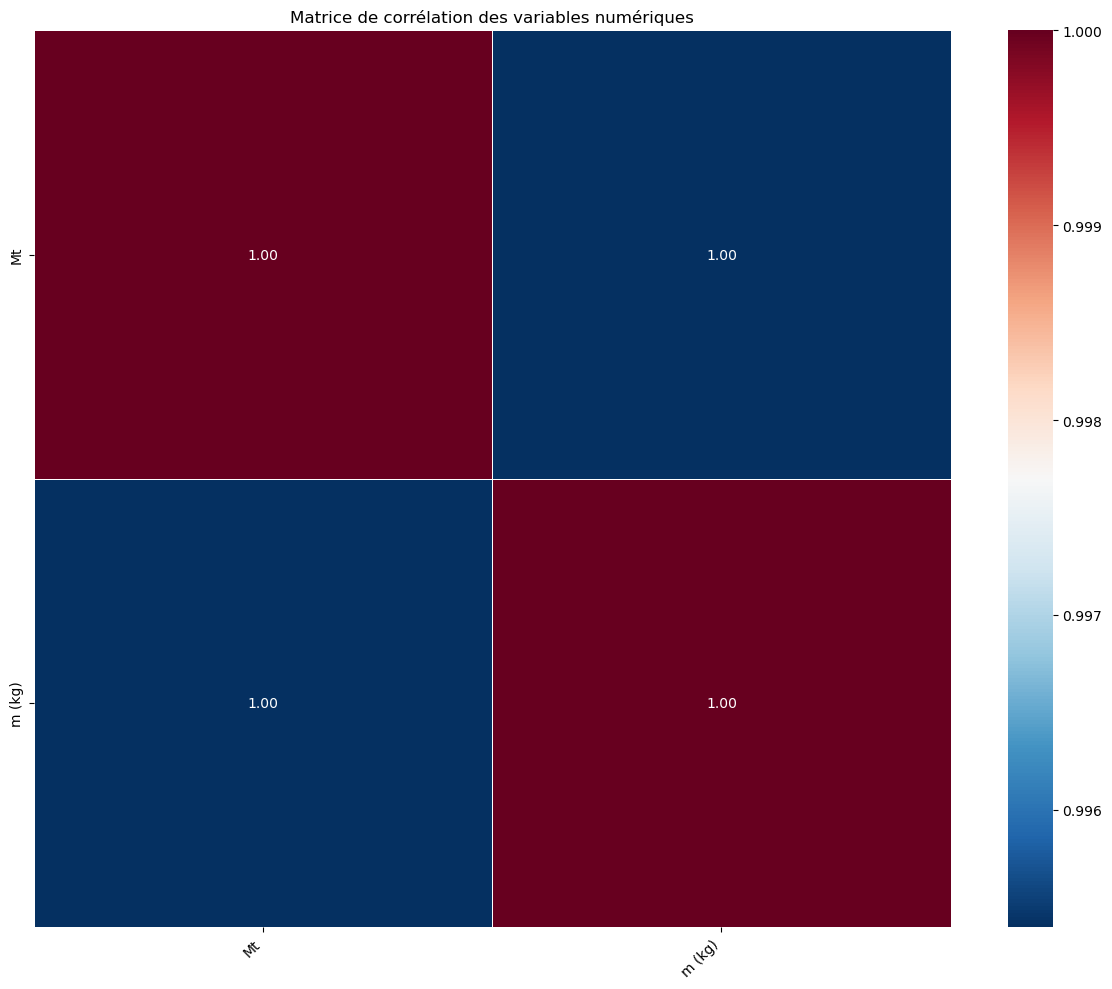

In [16]:
df_masse = df[['Mt', 'm (kg)']]
plot_correlation_matrix(df_masse)

On se rend compte qu'il y a une **forte corrélataion** entre ces 2 variables, qui pourrait entrainer une **colinéarité**. Nous prenons la décision de ne garder que la masse à vide (m (kg)).

In [17]:
df = df.drop('Mt', axis=1)

# <font color='#3585CD'>Gestion des doublons</font>

## Nombre de doublons

In [18]:
print(f"Nombre de doublons : {df.duplicated().sum()}")

Nombre de doublons : 3503825


## Supression des doublons

In [19]:
# Suppression des doublons
df.drop_duplicates(inplace =True)

In [20]:
# Vérification qu'il n'y ait plus de doublons
print(f"Nombre de doublons : {df.duplicated().sum()}")

Nombre de doublons : 0


In [21]:
# Nombres de lignes restantes
print(f"Il reste {df.shape[0]} lignes dans notre dataset.")

Il reste 24655 lignes dans notre dataset.


In [22]:
# Ré initialisation des index
df = df.reset_index(drop=True)

# <font color='#3585CD'>Renommage des colonnes</font>

Pour plus de compréhension, nous allons renommer les colonnes suivantes :



*   Mk : Marque
*   Cn : Modele
*   Ewltp (g/km) : CO2
*   Ft : Carburant
*   ec (cm3) : Cylindrée moteur
*   ep (KW) : Puissance moteur
*   Fuel consumption : Consommation carburant


In [23]:
renommage = {
    'Mk': 'Marque',
    'Cn': 'Modèle',
    'm (kg)' : 'Masse à vide',
    'Ewltp (g/km)': 'CO2',
    'Ft': 'Carburant',
    'ec (cm3)': 'Cylindrée moteur',
    'ep (KW)': 'Puissance moteur',
    'Fuel consumption': 'Consommation carburant'
}

# Application du renommage
df.rename(columns=renommage, inplace=True)

In [24]:
df.head(10)

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant
0,JEEP,RENEGADE,1845.0,49,petrol/electric,1332.0,96.0,2.0
1,JEEP,WRANGLER,1883.0,244,petrol,1995.0,200.0,10.8
2,JEEP,WRANGLER,1972.0,259,petrol,1995.0,200.0,11.5
3,JEEP,WRANGLER,1972.0,258,petrol,1995.0,200.0,11.5
4,JEEP,WRANGLER UNLIMITED,2348.0,79,petrol/electric,1995.0,200.0,3.5
5,JEEP,WRANGLER UNLIMITED,2409.0,94,petrol/electric,1995.0,200.0,4.1
6,HONDA,HR-V,1452.0,122,petrol,1498.0,79.0,5.4
7,JEEP,RENEGADE,1395.0,145,petrol,999.0,88.0,6.4
8,JEEP,RENEGADE,1395.0,146,petrol,999.0,88.0,6.4
9,JEEP,RENEGADE,1395.0,149,petrol,1332.0,110.0,6.6


# <font color='#3585CD'>Faut-il garder les véhicules électriques et hydrogènes ?</font>
Notre objectif est de **prédire les émissions directes de CO2**. Garder les véhicules électriques et hydrogènes risque de biaiser notre modèle. Nous allons donc **exclure les véhicules électriques et hydrogènes** de notre dataset

In [25]:
# Vérification des émissions de CO2 des véhicules hydrogènes avant exclusion
df_hydrogen = df[df["Carburant"] == "hydrogen"]
df_hydrogen['CO2'].value_counts()

CO2
0    4
Name: count, dtype: int64

In [26]:
# Nous excluons les véhicules électriques et hydrogènes
df = df[(df["Carburant"] != "electric") & (df["Carburant"] != "hydrogen")]

In [27]:
# Nombres de lignes restantes
print(f"Il reste {df.shape[0]} lignes dans notre dataset.")

Il reste 23935 lignes dans notre dataset.


# <font color='#3585CD'>Traitement des valeurs manquantes</font>

In [28]:
data_na = display_missing_values(df)
data_na

,Colonne,Valeurs manquantes (%),Nombre de valeurs manquantes,Type
0,Masse à vide,0.004178,1,float64
1,Consommation carburant,0.004178,1,float64


Il nous reste 2 variables à traiter.

## Gestion des valeurs manquantes de la colonne Consommation carburant

Regardons la ligne dont la variable Consommation carburant est nulle :

In [29]:
df_fc_na = df[df['Consommation carburant'].isna()]
df_fc_na

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant
23942,LAND ROVER,RANGE ROVER EVOQUE,NaN,137,diesel,1998.0,120.0,NaN


Nous allons gérer cette ligne en recherchant des modèles équivalents dans notre dataset :

In [30]:
# regardons si d'autres modeles RANGE ROVER EVOQUE sont renseignés
df_jag_evoque = df[(df['Modèle'] == 'RANGE ROVER EVOQUE') & (df['Carburant'] == 'diesel') & (~df['Consommation carburant'].isna())]
df_jag_evoque.head()

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant
2931,LAND ROVER,RANGE ROVER EVOQUE,1967.0,170,diesel,1998.0,120.0,6.5
2932,LAND ROVER,RANGE ROVER EVOQUE,1992.0,172,diesel,1998.0,150.0,6.6
2933,LAND ROVER,RANGE ROVER EVOQUE,1992.0,175,diesel,1998.0,150.0,6.7
2934,LAND ROVER,RANGE ROVER EVOQUE,1992.0,173,diesel,1998.0,150.0,6.6
2935,LAND ROVER,RANGE ROVER EVOQUE,1992.0,174,diesel,1998.0,150.0,6.6


Plusieurs modèles ayant les mêmes caractéristiques sont présents dans notre dataset. Nous pouvons remplacer la valeur manquante par la **moyenne** de cette même variable des modèles similaires : 

In [31]:
# Nous récupérons la consommation de carburant moyenne pour le même modèle
fc_mean_jag_evoque = df_jag_evoque['Consommation carburant'].mean().round(1)
print(f"La moyenne de la consommation de carburant est de {fc_mean_jag_evoque}")

La moyenne de la consommation de carburant est de 6.5


In [32]:
# nous attribuons la valeur fc_mean_jag_evoque
df.loc[(df["Modèle"] == "RANGE ROVER EVOQUE") & (df['Consommation carburant'].isna()), "Consommation carburant"] = fc_mean_jag_evoque

In [33]:
# vérification des valeurs manquantes
data_na = display_missing_values(df)
data_na

,Colonne,Valeurs manquantes (%),Nombre de valeurs manquantes,Type
0,Masse à vide,0.004178,1,float64


## Gestion des valeurs manquantes de la colonne Masse à vide

In [34]:
data_na = display_missing_values(df)
data_na

,Colonne,Valeurs manquantes (%),Nombre de valeurs manquantes,Type
0,Masse à vide,0.004178,1,float64


Regardons la ligne dont la variable Masse àvide est nulle :

In [35]:
# récupération de la ligne dont la masse est égale à NaN
df_mkg_na = df[df['Masse à vide'].isna()]
df_mkg_na

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant
23942,LAND ROVER,RANGE ROVER EVOQUE,NaN,137,diesel,1998.0,120.0,6.5


Recherchons dans le dataset si nous avons des modèles équivalents dont la variable Masse à vide n'est **pas nulle** : 

In [36]:
df_jag_lr = df[(df['Modèle'] == 'RANGE ROVER EVOQUE') & (df['Carburant'] == 'diesel') & (df['Puissance moteur'] == 120) & (~df['Masse à vide'].isna())]
df_jag_lr

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant
2931,LAND ROVER,RANGE ROVER EVOQUE,1967.0,170,diesel,1998.0,120.0,6.5
2936,LAND ROVER,RANGE ROVER EVOQUE,1967.0,173,diesel,1998.0,120.0,6.6
2937,LAND ROVER,RANGE ROVER EVOQUE,1967.0,171,diesel,1998.0,120.0,6.5
2940,LAND ROVER,RANGE ROVER EVOQUE,1967.0,174,diesel,1998.0,120.0,6.6
2941,LAND ROVER,RANGE ROVER EVOQUE,1967.0,172,diesel,1998.0,120.0,6.6
2943,LAND ROVER,RANGE ROVER EVOQUE,1967.0,172,diesel,1998.0,120.0,6.5
2969,LAND ROVER,RANGE ROVER EVOQUE,1855.0,164,diesel,1998.0,120.0,6.3
2970,LAND ROVER,RANGE ROVER EVOQUE,1855.0,160,diesel,1998.0,120.0,6.1
2971,LAND ROVER,RANGE ROVER EVOQUE,1855.0,165,diesel,1998.0,120.0,6.3
2972,LAND ROVER,RANGE ROVER EVOQUE,1855.0,162,diesel,1998.0,120.0,6.2


Plusieurs modèles ayant les mêmes caractéristiques sont présents dans notre dataset. Nous pouvons remplacer la valeur manquante par la **moyenne** de cette même variable des modèles similaires : 

In [37]:
# Nous récupérons la masse moyenne pour le même modèle
fc_mean_masse_jag_evoque = df_jag_evoque['Masse à vide'].mean().round(1)
print(f"La moyenne de la masse est de {fc_mean_masse_jag_evoque}")

La moyenne de la masse est de 1955.3


In [38]:
# nous attribuons la valeur fc_mean_masse_jag_evoque
df['Masse à vide'] = df['Masse à vide'].fillna(fc_mean_masse_jag_evoque)

In [39]:
# Vérification de l'assignation de la valeur
df.loc[23942].to_frame().T

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant
23942,LAND ROVER,RANGE ROVER EVOQUE,1955.3,137,diesel,1998.0,120.0,6.5


In [40]:
data_na = display_missing_values(df)
data_na

,Colonne,Valeurs manquantes (%),Nombre de valeurs manquantes,Type


Nous n'avons **plus de valeurs manquantes** dans notre dataset.

In [41]:
# ré inisialisation des indexes
df = df.reset_index(drop=True)
df.head()

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant
0,JEEP,RENEGADE,1845.0,49,petrol/electric,1332.0,96.0,2.0
1,JEEP,WRANGLER,1883.0,244,petrol,1995.0,200.0,10.8
2,JEEP,WRANGLER,1972.0,259,petrol,1995.0,200.0,11.5
3,JEEP,WRANGLER,1972.0,258,petrol,1995.0,200.0,11.5
4,JEEP,WRANGLER UNLIMITED,2348.0,79,petrol/electric,1995.0,200.0,3.5


# <font color='#3585CD'>Distribution des variables catégorielles</font>

## Analyse par marque

### Valeurs uniques

In [42]:
sorted(df['Marque'].unique())

['ALFA ROMEO',
 'ALPINA',
 'ALPINE',
 'ASTON MARTIN',
 'AUDI',
 'BENTLEY',
 'BMW',
 'BUGATTI',
 'CADILLAC',
 'CASELANI',
 'CATERHAM',
 'CHEVROLET',
 'CITROEN',
 'CUPRA',
 'DACIA',
 'DALLARA',
 'DONKERVOORT',
 'DR',
 'DS',
 'FERRARI',
 'FIAT',
 'FORD',
 'FORD-CNG-TECHNIK',
 'HONDA',
 'HYUNDAI',
 'INEOS',
 'JAGUAR',
 'JEEP',
 'KIA',
 'KTM',
 'LAMBORGHINI',
 'LAND ROVER',
 'LEXUS',
 'LOTUS',
 'LYNK&CO',
 'MASERATI',
 'MAZDA',
 'MC LAREN',
 'MCLAREN',
 'MERCEDES AMG',
 'MERCEDES BENZ',
 'MERCEDES-BENZ',
 'MG',
 'MINI',
 'MITSUBISHI',
 'MITSUBISHI MOTORS (THAILAND)',
 'MITSUBISHI MOTORS CORPORATION',
 'MITSUBISHI MOTORS THAILAND',
 'MORGAN',
 'NISSAN',
 'OPEL',
 'PEUGEOT',
 'PORSCHE',
 'RENAULT',
 'ROLLS ROYCE',
 'ROLLS-ROYCE',
 'SEAT',
 'SECMA',
 'SKODA',
 'SSANGYONG',
 'SUBARU',
 'SUZUKI',
 'TOYOTA',
 'VOLKSWAGEN',
 'VOLVO']

### Remplacement

Certaines valeurs peuvent être regroupées, comme par exemple :

*   'MC LAREN', 'MCLAREN'
*   'MERCEDES AMG', 'MERCEDES BENZ', 'MERCEDES-BENZ'
*   'MITSUBISHI', 'MITSUBISHI MOTORS CORPORATION', 'MITSUBISHI MOTORS THAILAND'


In [43]:
# valeurs à remplacer
replace_mk = {'MC LAREN' : 'MCLAREN',
              'MERCEDES AMG' : 'MERCEDES BENZ',
              'MERCEDES-BENZ' : 'MERCEDES BENZ',
              'MITSUBISHI MOTORS CORPORATION' : 'MITSUBISHI',
              'MITSUBISHI MOTORS THAILAND' : 'MITSUBISHI',
              'MITSUBISHI MOTORS (THAILAND)' : 'MITSUBISHI',
              'FORD-CNG-TECHNIK' : 'FORD',
              'ROLLS ROYCE' : 'ROLLS-ROYCE'}
df['Marque'] = df['Marque'].replace(replace_mk)

In [44]:
print(f"Il y a {df['Marque'].nunique()} marques dans le dataset.")

Il y a 57 marques dans le dataset.


### Analyse

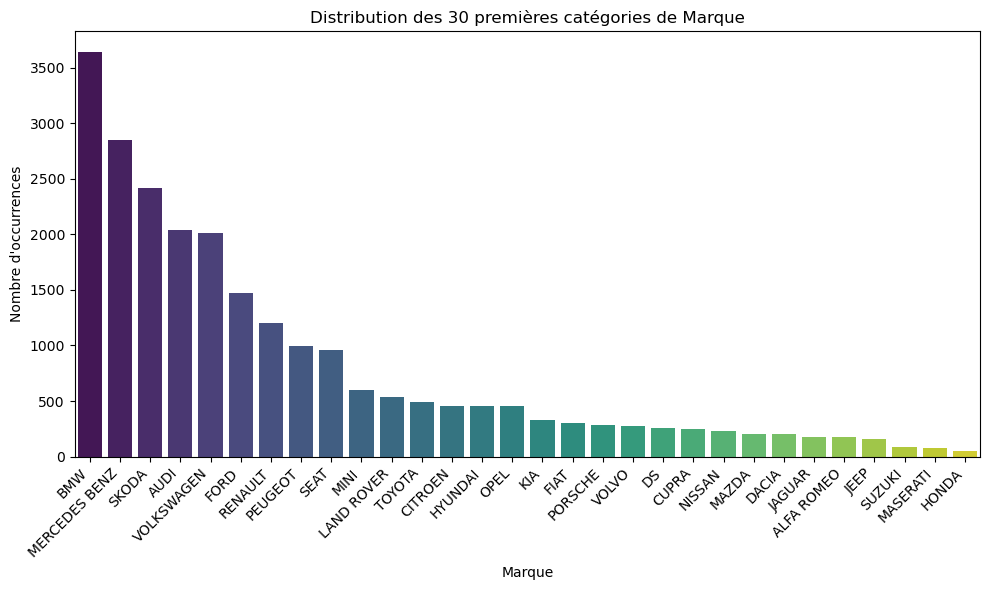

In [45]:
analyser_variable_categorielle(df, 'Marque', 30, False)

Sans surpise, nous nous apercevons que les marques les **plus représentées** sont les **plus connues** : BMW, Mercedes, Skoda, Audi, Volswagen, Ford, Peugeot ...

## Analyse par carburant

### Valeurs uniques

In [46]:
sorted(df['Carburant'].unique())

['diesel', 'diesel/electric', 'e85', 'lpg', 'ng', 'petrol', 'petrol/electric']

### Remplacement

Certaines valeurs peuvent être regroupées :

*   'diesel/electric' & 'petrol/electric' sont des véhicules hybrides. Nous décidons de créer une catégorie 'hybride' afin de les regrouper.
*   'lpg' & 'ng' sont des énergies au gaz. Nous décidons de créer une catégorie 'gaz' afin de les regrouper.
*   'petrol' sera renommé en 'essence' pour plus de compréhension.
*   'e85' est un carburant de type 'essence'. Nous décidons de "l'absorber" dans la catégorie 'essence'.


In [47]:
replace_ft = {
              'petrol' : 'essence',
              'diesel/electric' : 'hybride',
              'petrol/electric' : 'hybride',
              'lpg' : 'gaz',
              'ng' : 'gaz',
              'e85' : 'essence'}
df['Carburant'] = df['Carburant'].replace(replace_ft)

### Analyse

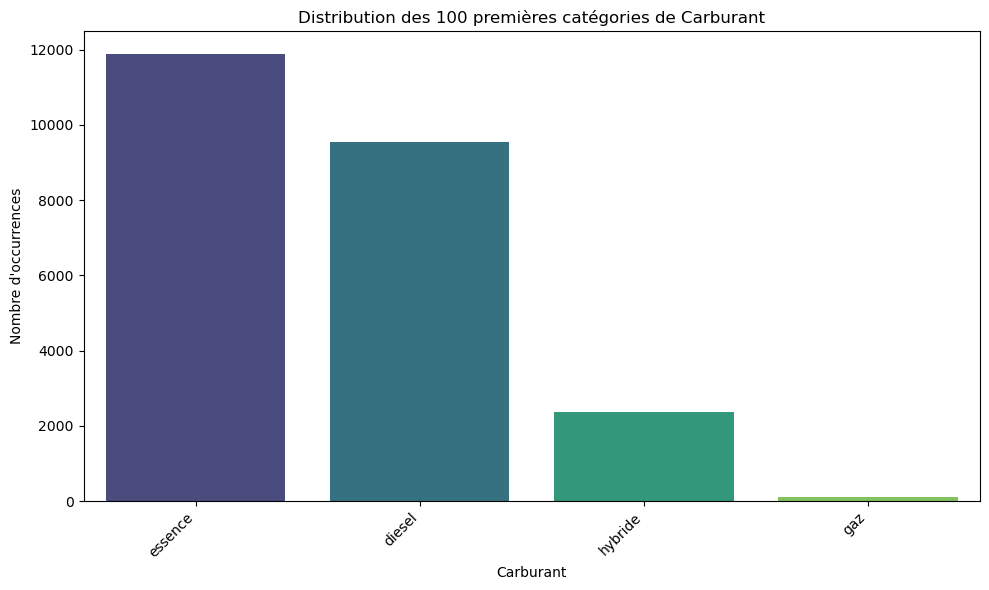

In [48]:
analyser_variable_categorielle(df=df, variable='Carburant', display_array=False)

Les carburants majoritaires sont : 
*   Essence
*   Diesel
*   Hybride

## Analyse par modèle de voiture

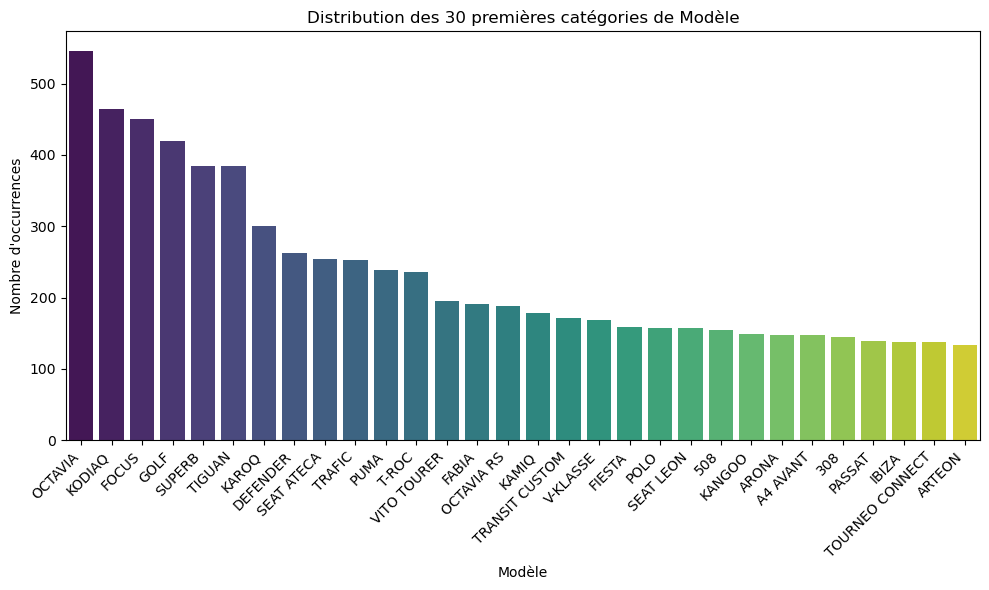

In [49]:
analyser_variable_categorielle(df, 'Modèle', 30, display_array=False)

Sans surprise, les modèles les plus nombreux sont des **"classiques"** du monde automobile : Octovia et Kodiaq de Skoda, Focus de Ford, Golf de Volkswagen ...

# <font color='#3585CD'>Distribution des variables numériques</font>

## Sélection des colonnes numériques

In [50]:
# Sélection des colonnes numériques
num_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_vars

['Masse à vide',
 'CO2',
 'Cylindrée moteur',
 'Puissance moteur',
 'Consommation carburant']

## Analyse de la masse du véhicule Masse à vide

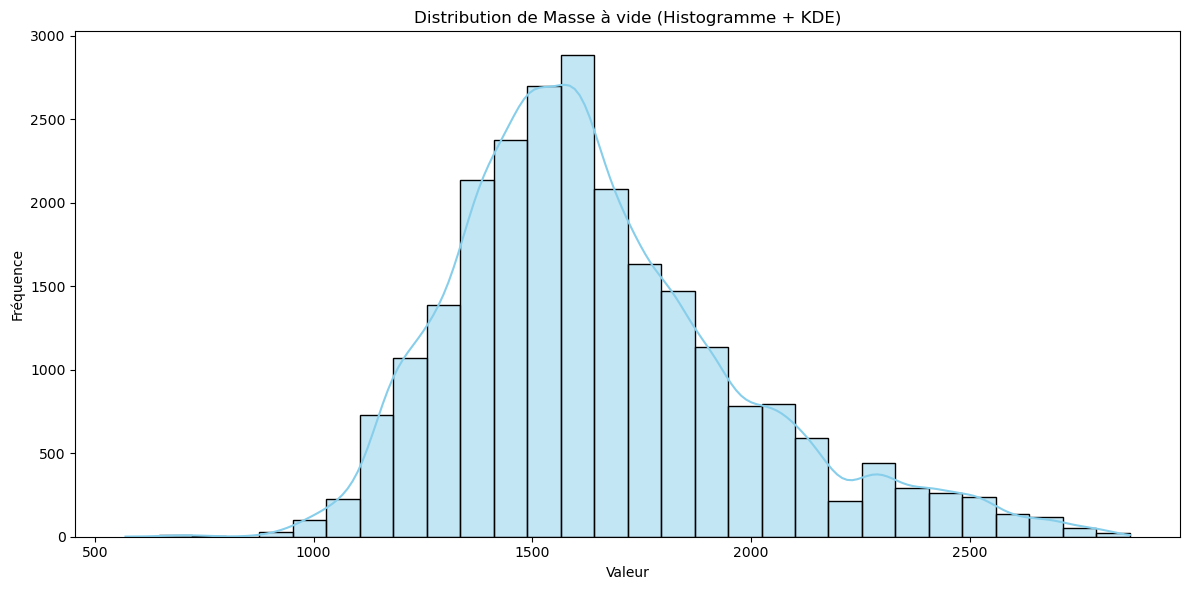

In [51]:
analyser_variables_numeriques(df, ['Masse à vide'])

La classe entre **1400 et 1700 kg** contient la plus grande concentration de véhicules.

## Analyse des émissions spécifiques de CO2

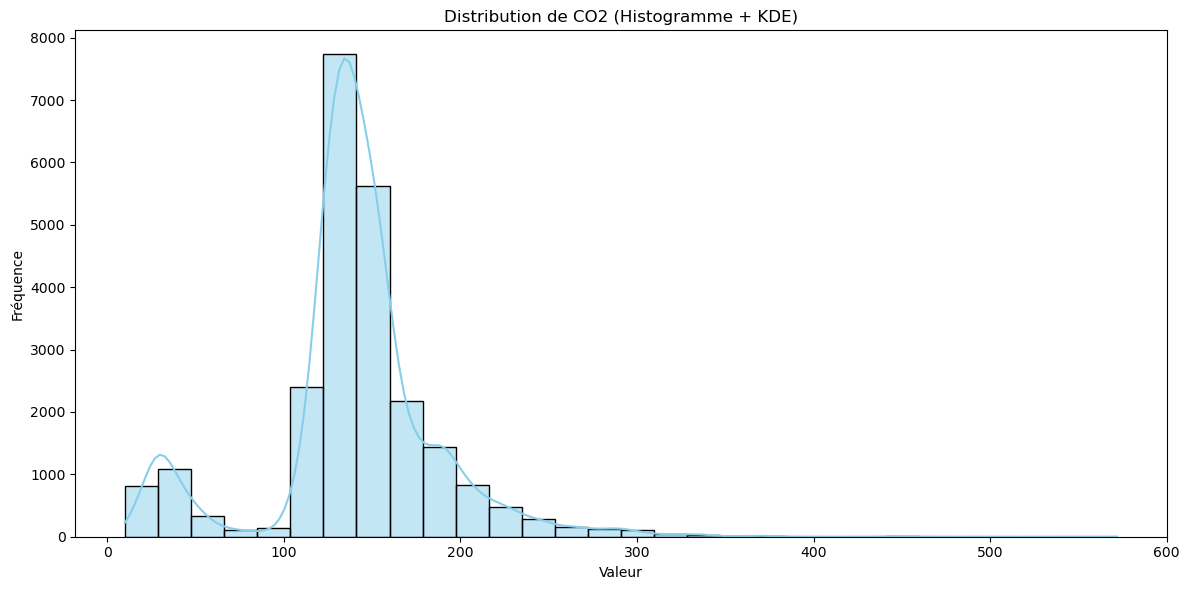

In [52]:
analyser_variables_numeriques(df, ['CO2'], 30)

Nous observons un **pic massif** entre **100 et 150 g/km**, signifiant que la majorité des véhicules se trouvent dans cette fourchette.

Nous observons également un **pic secondaire** plus petit entre **20 et 50 g/km**, probablement des véhicules hybrides.

Enfin , une **longue traîne à droite** est visible, signifiant que quelques véhicules **très polluants** sont présents dans notre dataset (SUV, utilitaires, sportives).

## Analyse de la cylindrée moteur

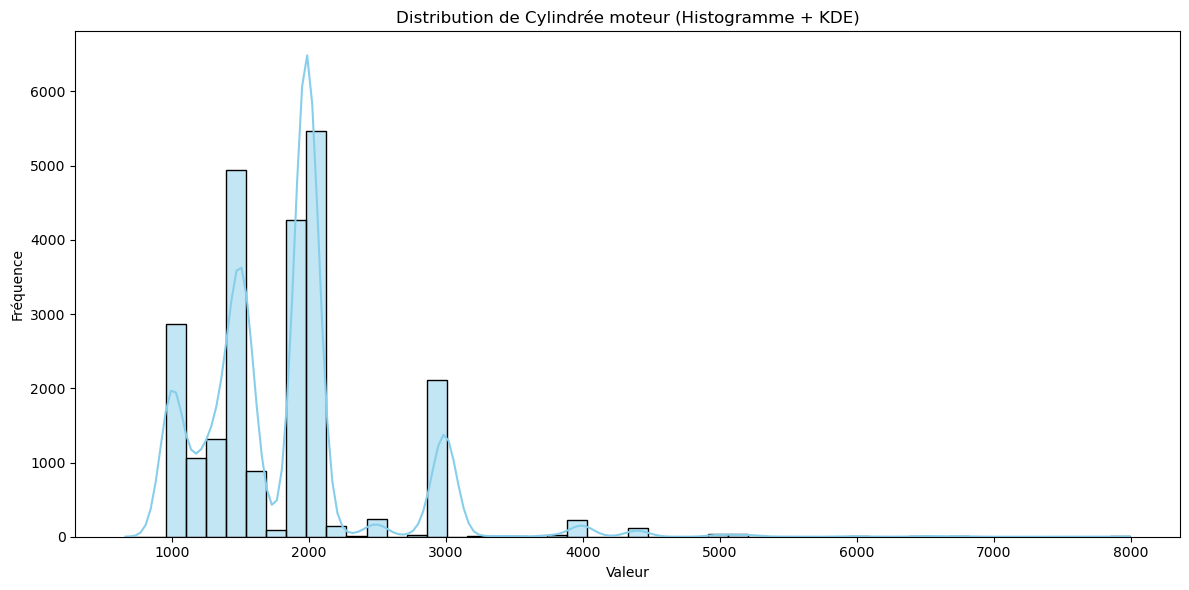

In [53]:
analyser_variables_numeriques(df, ['Cylindrée moteur'], 50)

Il y a plusieurs **pics nets** : 

* Autour de 1200 cm³
* Puis 1600 cm³,
* Un gros pic vers 1900 cm³
* Un 4e petit pic vers 3000 cm³, 
* Et quelques cas rares au-delà de 4000 cm³.

Peut-être segmenter cette colonne ? 
* < 1300 : Petite cylindrée	
* 1300 – 1599 : Cylindrée Moyenne
* 1600 – 1999: Cylindrée standard	
* 2000 – 2999 : Grosse cylindrée
* 3000 et plus : Très grosse cylindrée

In [54]:
bins = [0, 1299, 1599, 1999, 2999, float('inf')]
labels = [
    'Petite (≤1.3L)',
    'Moyenne (1.3–1.6L)',
    'Standard (1.6–2.0L)',
    'Grosse (2.0–3.0L)',
    'Très grosse (>3.0L)'
]

df['Classe_Cylindree'] = pd.cut(df['Cylindrée moteur'], bins=bins, labels=labels, right=True)


In [55]:
df.head()

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant,Classe_Cylindree
0,JEEP,RENEGADE,1845.0,49,hybride,1332.0,96.0,2.0,Moyenne (1.3–1.6L)
1,JEEP,WRANGLER,1883.0,244,essence,1995.0,200.0,10.8,Standard (1.6–2.0L)
2,JEEP,WRANGLER,1972.0,259,essence,1995.0,200.0,11.5,Standard (1.6–2.0L)
3,JEEP,WRANGLER,1972.0,258,essence,1995.0,200.0,11.5,Standard (1.6–2.0L)
4,JEEP,WRANGLER UNLIMITED,2348.0,79,hybride,1995.0,200.0,3.5,Standard (1.6–2.0L)



Analyse de la variable : Classe_Cylindree 


,Libellé,Total,Pourcentage
0,Standard (1.6–2.0L),9833,41.082097
1,Moyenne (1.3–1.6L),7135,29.809902
2,Petite (≤1.3L),3946,16.486317
3,Grosse (2.0–3.0L),2522,10.536871
4,Très grosse (>3.0L),499,2.084813


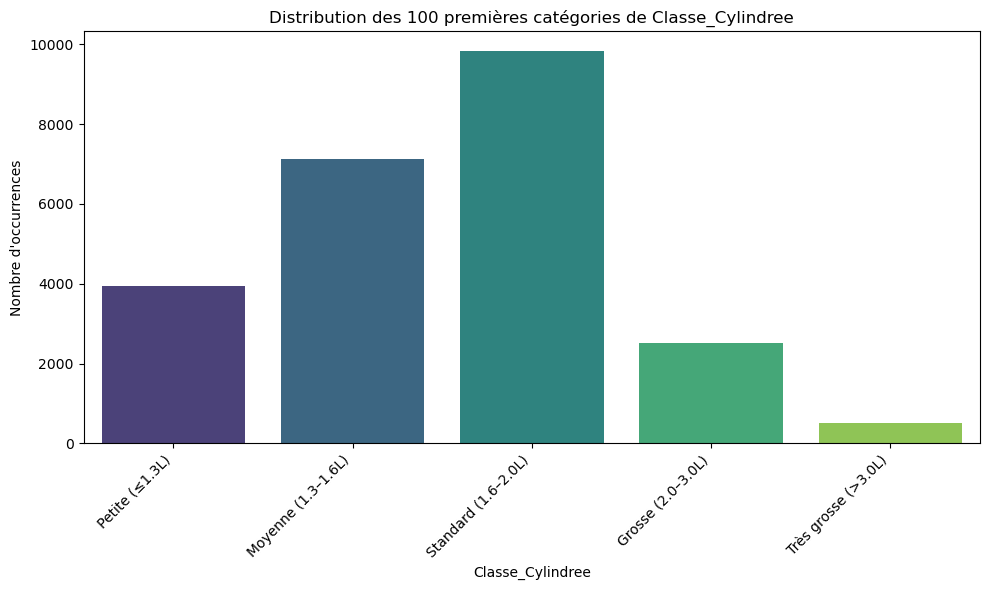

In [56]:
analyser_variable_categorielle(df, 'Classe_Cylindree')

## Analyse de la puissance du moteur

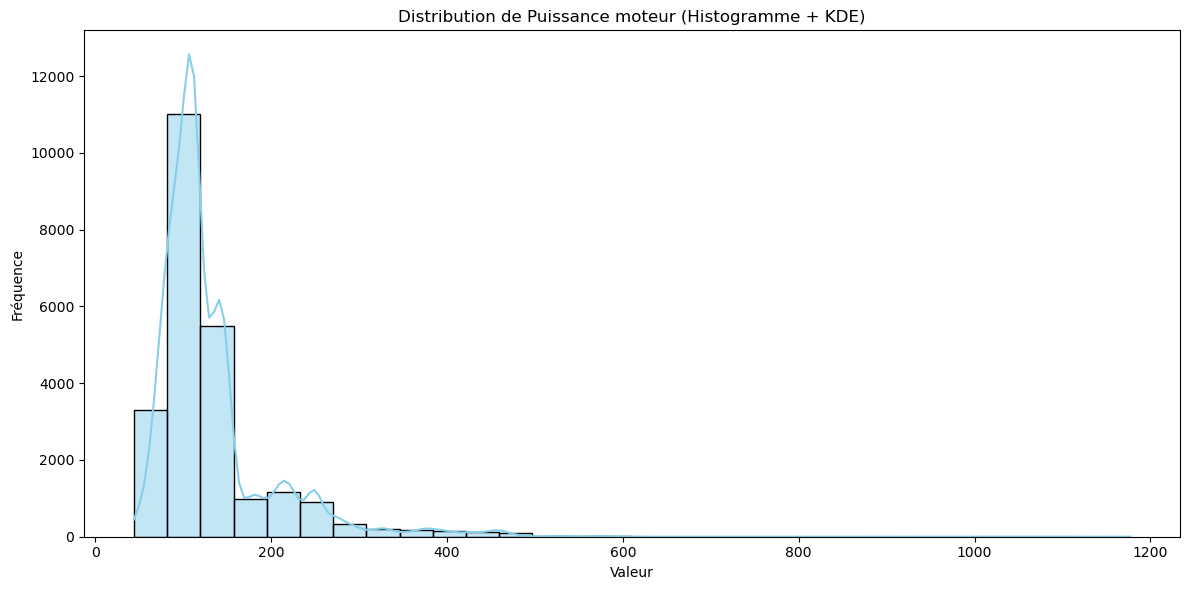

In [57]:
analyser_variables_numeriques(df, ['Puissance moteur'])

La majorité des véhicules ont une puissance entre **50 et 150 ch**.

Le pic majeur est clairement autour de **100 ch**.

Ensuite, la fréquence chute fortement à partir de **150–160 ch**, mais il reste une queue étalée jusqu’à plus de 400 ch.

Peut-être segmenter cette colonne ? 
* < 110 ch : faible
* 110 – 149 ch : moyenne
* 150 – 199 ch : intermédiaire
* 200 - 299 ch: élevée
* sup. à 300 ch : très elevée

In [58]:
bins = [0, 109, 149, 199, 299, float('inf')]
labels = [
    'Faible (<110 ch)',
    'Moyenne (110–149 ch)',
    'Performante (150–199 ch)',
    'Élevée (200–299 ch)',
    'Très élevée (≥300 ch)'
]

df['Classe_Puissance'] = pd.cut(df['Puissance moteur'], bins=bins, labels=labels, right=True)

In [59]:
df.head()

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant,Classe_Cylindree,Classe_Puissance
0,JEEP,RENEGADE,1845.0,49,hybride,1332.0,96.0,2.0,Moyenne (1.3–1.6L),Faible (<110 ch)
1,JEEP,WRANGLER,1883.0,244,essence,1995.0,200.0,10.8,Standard (1.6–2.0L),Élevée (200–299 ch)
2,JEEP,WRANGLER,1972.0,259,essence,1995.0,200.0,11.5,Standard (1.6–2.0L),Élevée (200–299 ch)
3,JEEP,WRANGLER,1972.0,258,essence,1995.0,200.0,11.5,Standard (1.6–2.0L),Élevée (200–299 ch)
4,JEEP,WRANGLER UNLIMITED,2348.0,79,hybride,1995.0,200.0,3.5,Standard (1.6–2.0L),Élevée (200–299 ch)



Analyse de la variable : Classe_Puissance 


,Libellé,Total,Pourcentage
0,Moyenne (110–149 ch),10423,43.547107
1,Faible (<110 ch),8570,35.805306
2,Élevée (200–299 ch),2388,9.977021
3,Performante (150–199 ch),1782,7.445164
4,Très élevée (≥300 ch),772,3.225402


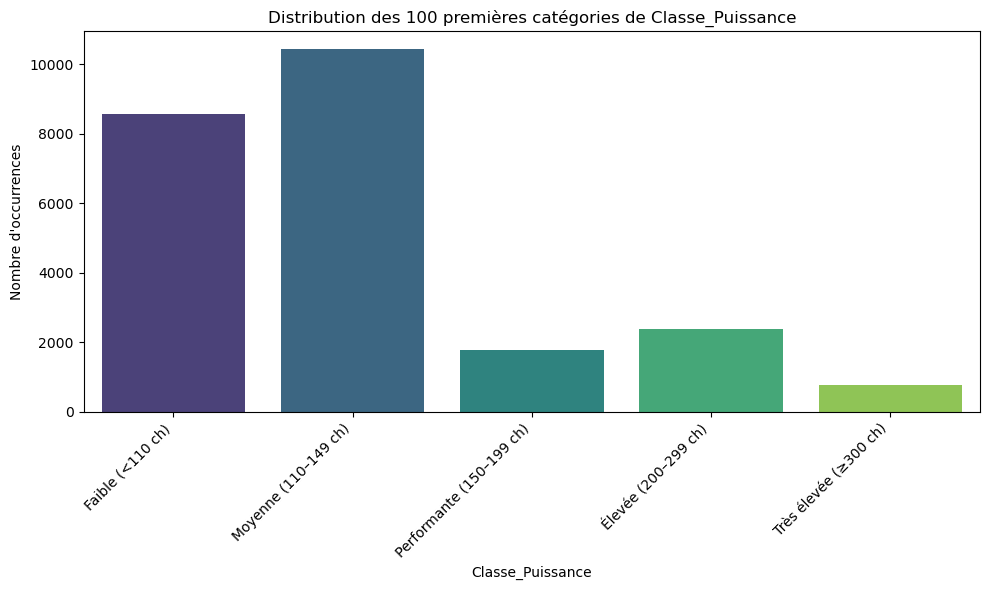

In [60]:
analyser_variable_categorielle(df, 'Classe_Puissance')

## Analyse de la Consommation carburant

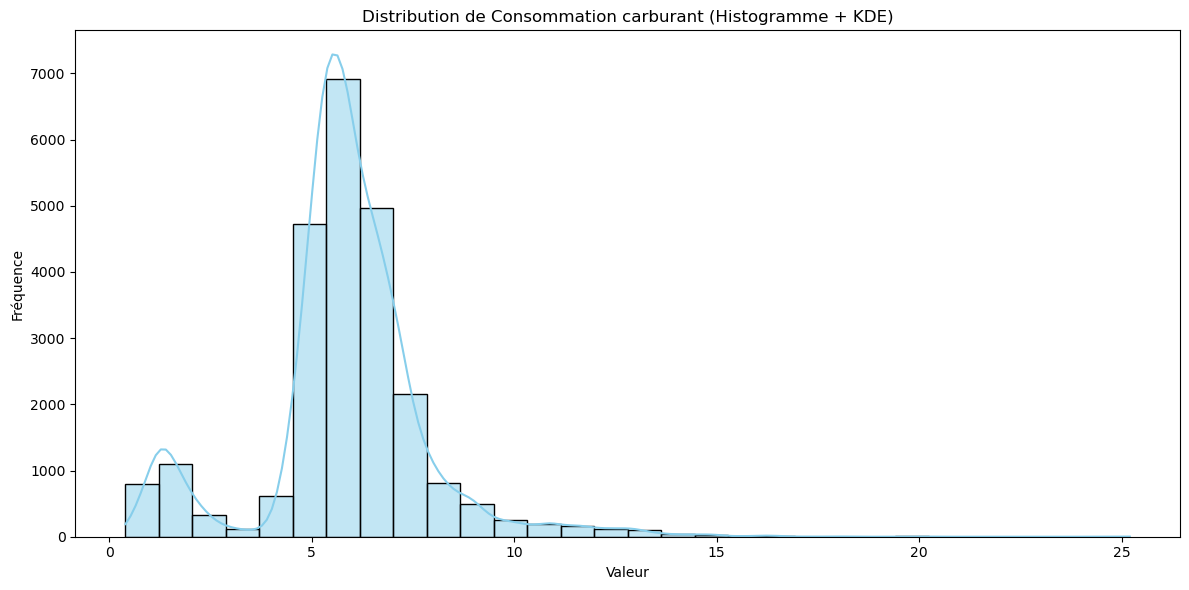

In [61]:
analyser_variables_numeriques(df, ['Consommation carburant'])

La consommation la plus fréquente se situe entre **5 et 6 L/100 km**, avec un pic net vers **5.5 L**.

Il y a quelques véhicules **extrêmement économes** (<3 L), probablement des véhicules hybrides et une **longue traîne à droite** jusqu’à 25 L/100 km, probablement des véhicules sportifs.

# <font color='#3585CD'>Création d'indicateurs</font>

Nous souhaitons créer quelques indicateurs afin de faciliter l'analyse et l'interprétation. Nous déciderons lors de la modélisation si nous les gardons ou pas.

## Indicateur de Charge Spécifique du Moteur (ICSM)

`ICSM = Puissance (kW) / Masse du véhicule (kg)`

**Interprétation** :

*   Faible ICSM → Voiture puissante et légère (moins d’effort, moins de CO₂).
*   Élevé ICSM → Voiture sous-motorisée (forte sollicitation, plus de CO₂).

In [62]:
df['ICSM'] = df['Puissance moteur'] / df['Masse à vide']

## Indicateur de Consommation Énergétique (ICE)

`ICE = Puissance (kW) / Cylindrée (cm³)`

**Interprétation** :

*   Faible ICE → Moteur optimisé (ex. turbo downsizing).
*   Élevé ICE → Moteur gourmand et peu efficient.

In [63]:
df['ICE'] = df['Puissance moteur'] / df['Cylindrée moteur']

## Indicateur de Densité Energétique du Carburant (IDEC)

`IDEC = Cylindrée (cm³) / Masse du véhicule (kg)`

**Interprétation** :

*   Faible IDEC → Moteur bien dimensionné (moins d’effort, moins de CO₂).
*   Élevé IDEC → Moteur sous-dimensionné (forte sollicitation, plus de CO₂).

In [64]:
df['IDEC'] = df['Cylindrée moteur'] / df['Masse à vide']

## Indicateur de Consommation Spécifique (ICS)

`ICS = Puissance produite (kWh) / Consommation de carburant (g)`

**Interprétation** :

*   Faible ICS : Moteur efficace, consomme moins de carburant et génère moins de CO₂ pour produire la même puissance.
*   Élevé ICS : Moteur inefficace, consomme plus de carburant et génère plus de CO₂ pour produire la même puissance.

In [65]:
df['ICS'] = df['Puissance moteur'] / df['Consommation carburant']

In [66]:
df.head()

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant,Classe_Cylindree,Classe_Puissance,ICSM,ICE,IDEC,ICS
0,JEEP,RENEGADE,1845.0,49,hybride,1332.0,96.0,2.0,Moyenne (1.3–1.6L),Faible (<110 ch),0.052033,0.072072,0.721951,48.000000
1,JEEP,WRANGLER,1883.0,244,essence,1995.0,200.0,10.8,Standard (1.6–2.0L),Élevée (200–299 ch),0.106213,0.100251,1.059480,18.518519
2,JEEP,WRANGLER,1972.0,259,essence,1995.0,200.0,11.5,Standard (1.6–2.0L),Élevée (200–299 ch),0.101420,0.100251,1.011663,17.391304
3,JEEP,WRANGLER,1972.0,258,essence,1995.0,200.0,11.5,Standard (1.6–2.0L),Élevée (200–299 ch),0.101420,0.100251,1.011663,17.391304
4,JEEP,WRANGLER UNLIMITED,2348.0,79,hybride,1995.0,200.0,3.5,Standard (1.6–2.0L),Élevée (200–299 ch),0.085179,0.100251,0.849659,57.142857


# <font color='#3585CD'>Analyse du CO2 en fonction de certaines variables</font>

### Analyse du CO2 en fonction de la masse du véhicule

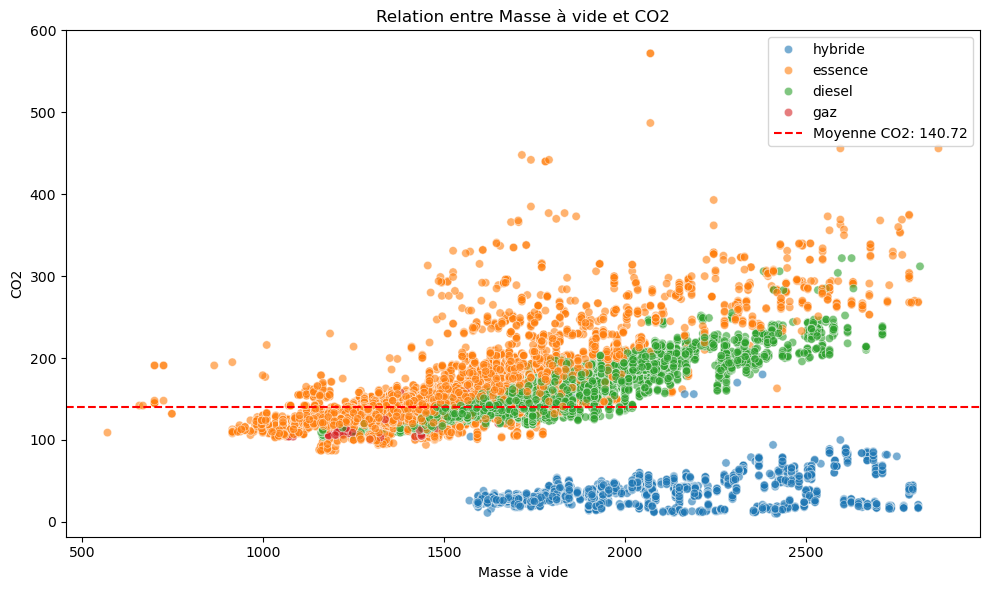

In [67]:
plot_scatter_co2(df, "Masse à vide")

Nous observons une **corrélation positive** entre la masse et le CO2, ce qui peut être logique : plus un véhicule est lourd, plus il consomme de carburant et donc plus il émet de de CO2.

Cependant, les véhicules Hybrides **"cassent"** cette logique : malgré une masse élevée les émissions de CO2 restent faibles.

Les véhicules Essence tendent à être **plus émissif** que les véhicules Diesel à masse équivalente.

### Analyse du CO2 en fonction de la puissance du moteur.

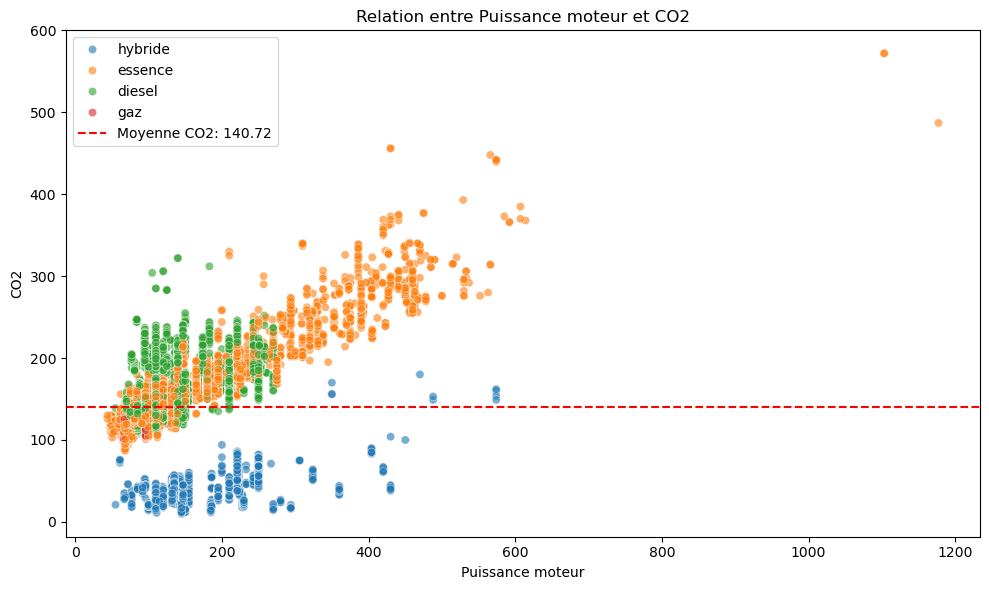

In [68]:
plot_scatter_co2(df, "Puissance moteur")

Nous observons une **corrélation positive** entre la puissance et le CO2 : plus un véhicule est puissant, plus il émet de CO2.

Les véhicules Hybrides sont clairement en-dessous de la ligne moyenne des émissions de CO2.

De très rares valeurs extrêmes sont présentes.

### Analyse du CO2 en fonction du carburant



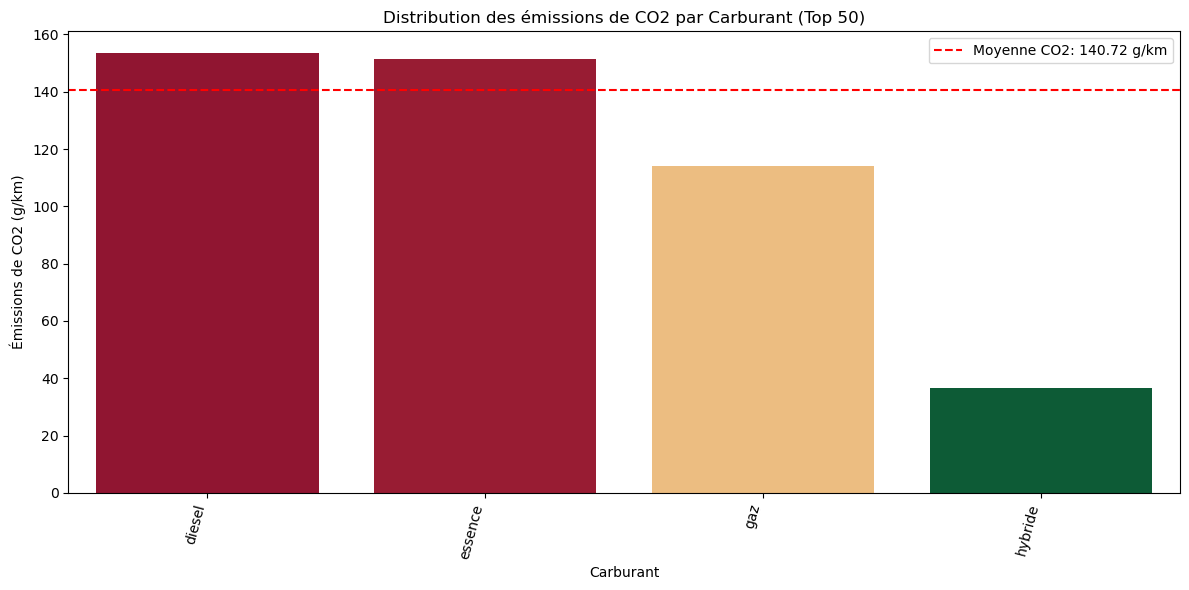

In [69]:
analyser_hist_co2_par_variable(df, 'Carburant')

Les véhicules Hybrides sont **nettement en dessous** que tous les autres carburants en matière d'émissions de CO2.

Les véhicules Diesel et Essence sont très **proches** (environ 150 g/km), et tous **au-dessus** de la moyenne.

Le Gaz naturel est une **alternative intéressante** qui est sous la moyenne.

### Analyse du CO2 en fonction de la marque

**Top des marques les plus polluantes**

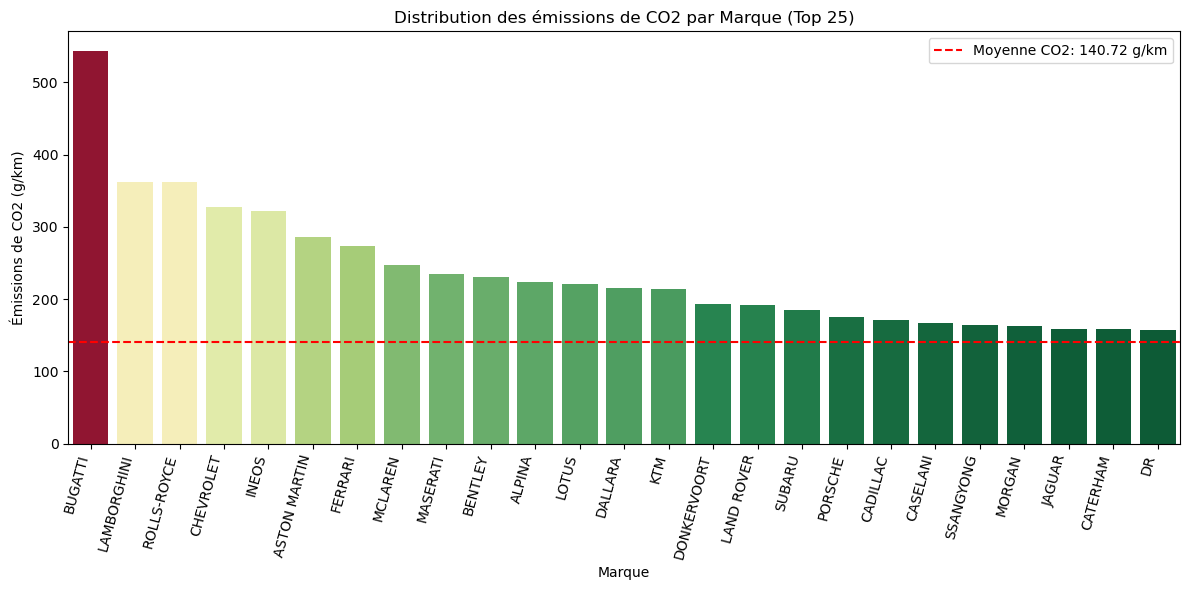

In [70]:
analyser_hist_co2_par_variable(df, 'Marque', 25)

La marque **Bugatti** est largement au dessus des autres marques avec plus de 500 g/km (sans surprise vu le type de véhicule).

Les marques **sportives/premium** (Lamborghini, Ferrari, McLaren...) dominent le haut du classement.

**Top des marques les moins polluantes**

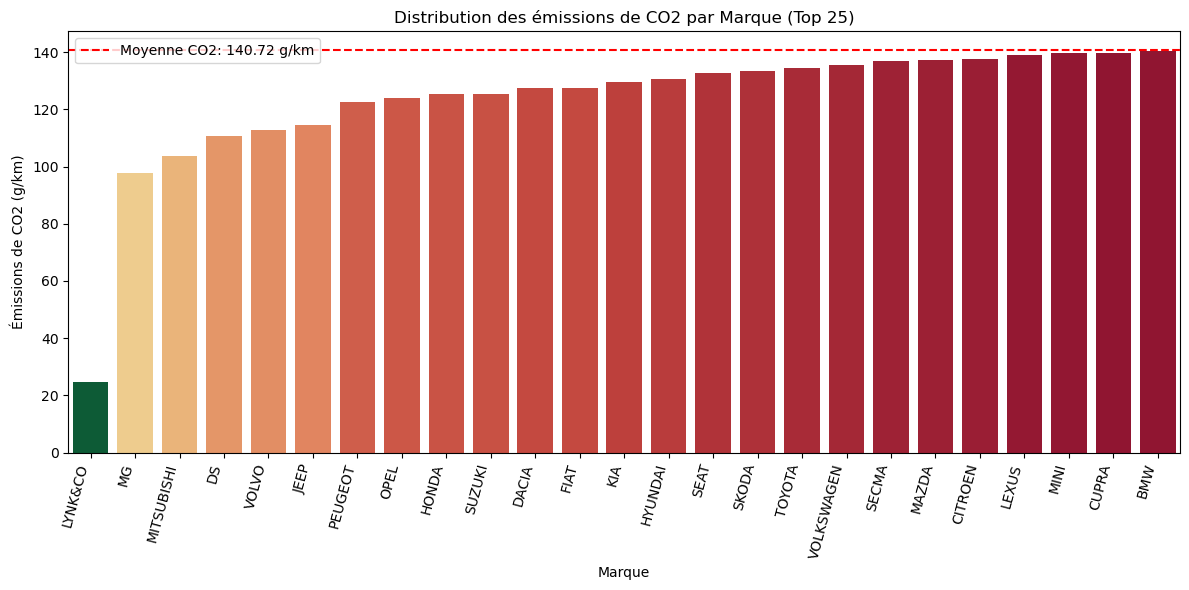

In [71]:
analyser_hist_co2_par_variable(df, 'Marque', 25, order='asc')

La marque **LYNK&CO** est largement en tête, probablement car sa flotte est quasi uniquement hybride.

La marque **MG** est aussi faible émettrice de CO2.

Les marques **européennes classiques** (Peugeot, Renault, Volkswagen) se situent autour de 125–140 g/km.

### Analyse du CO2 en fonction du modèle de voiture

**Top des modèles les plus polluants**

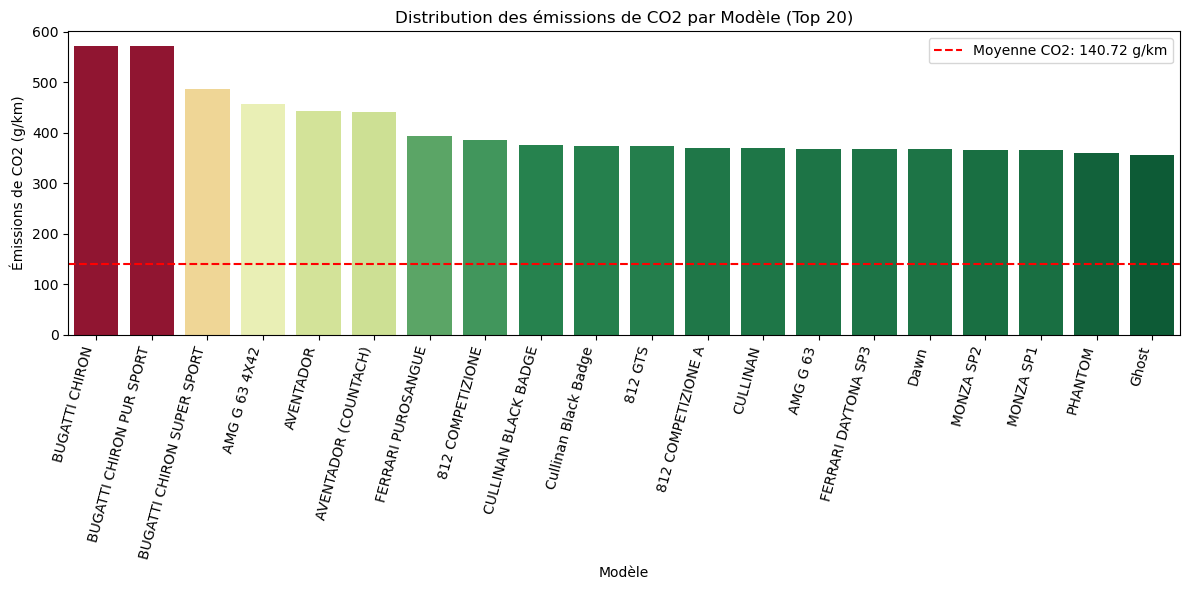

In [72]:
analyser_hist_co2_par_variable(df, 'Modèle', 20)

Ce Top 20 ne contient que des véhicules **"ultra-premium"** : Bugatti, Ferrari, Lamborghini, AMG, Rolls-Royce…

Ce sont tous des modèles très puissants, lourds, donc naturellement **très émissifs**.

La différence énorme avec la moyenne (140.72) montre à quel point ces modèles sont hors norme d'un point de vue environnementale.

**Top des modèles les moins polluants**

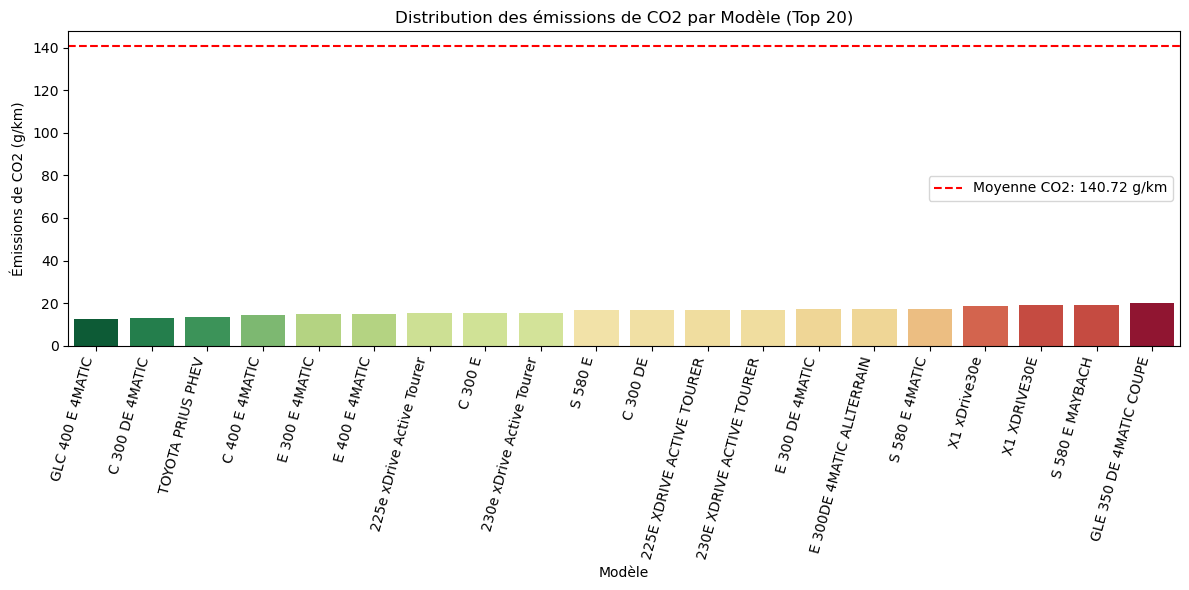

In [73]:
analyser_hist_co2_par_variable(df, 'Modèle', 20, order='asc')

Ces valeurs extrêmement faibles (entre 12 et 20 g/km) sont caractéristiques des **véhicules hybrides**, qui combinent moteur électrique/thermique.

Les marques Mercedes, BMW, Toyota dominent ce classement.

### Analyse du CO2 en fonction de la consommation

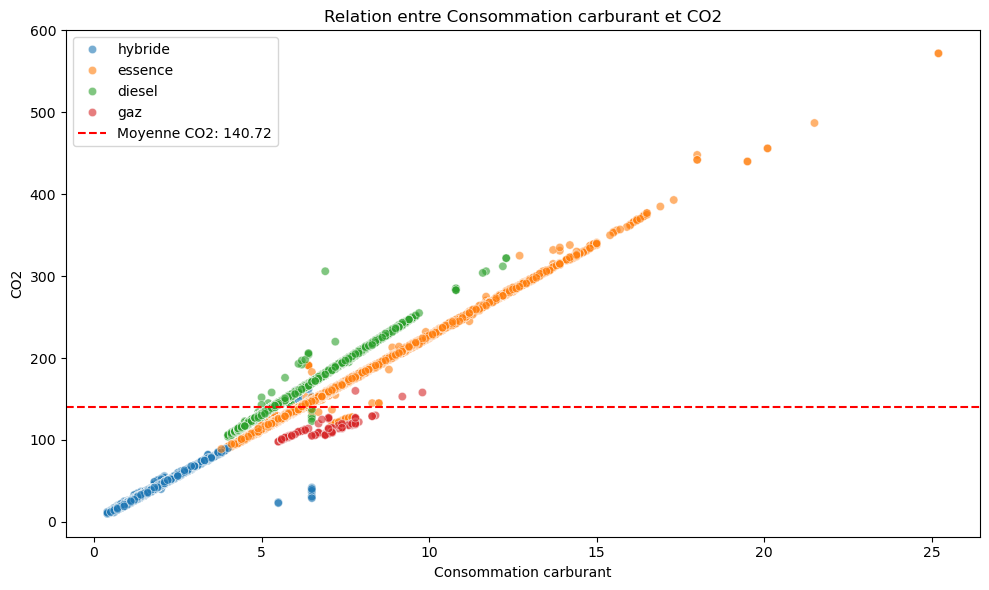

In [74]:
plot_scatter_co2(df, "Consommation carburant")

Nous observons une **relation quasi-linéaire** entre la consommation de carburant et le CO2 : plus un véhicule consomme de carburant, plus il émet de CO2.

Les véhicules Diesel ont tendance à **emettre moins de CO2** par rapport aux véhicules Essance.

Les véhicules Hybrides sont **concentrés en bas à gauche** : consommation de carburant faible et émissions de CO2 faibles.

### Analyse du CO2 en fonction de la classe de Puissance


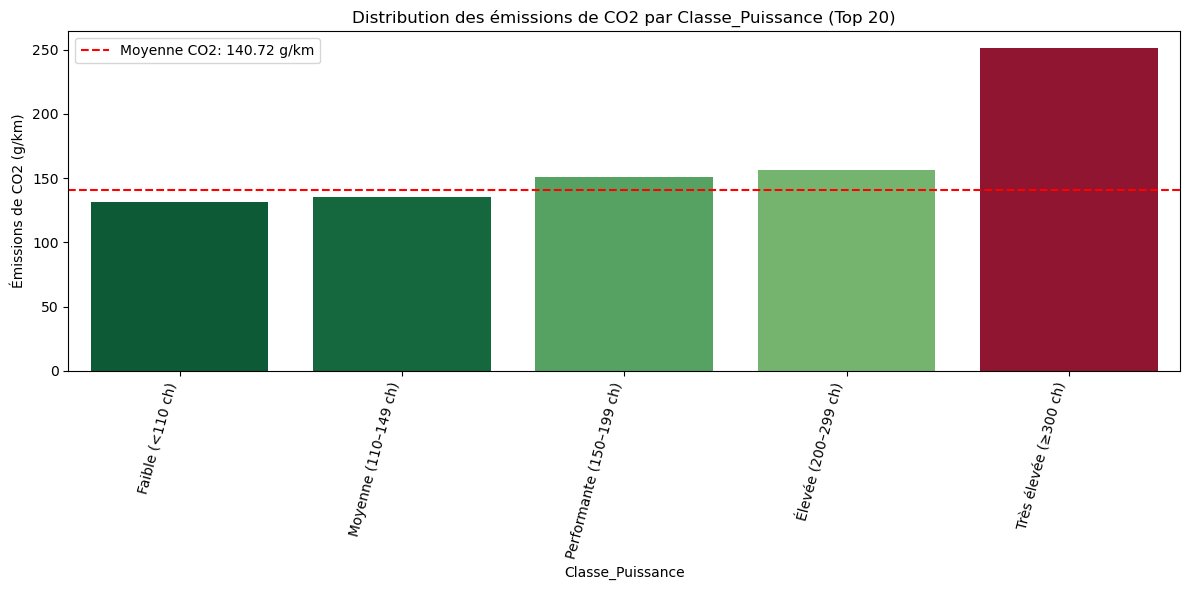

In [75]:
analyser_hist_co2_par_variable(df, 'Classe_Puissance', 20, order='asc')

Nous observons que plus la puissance est élevée plus les émissions de CO2 sont hautes.

### Analyse du CO2 en fonction de la classe de Cylindrée


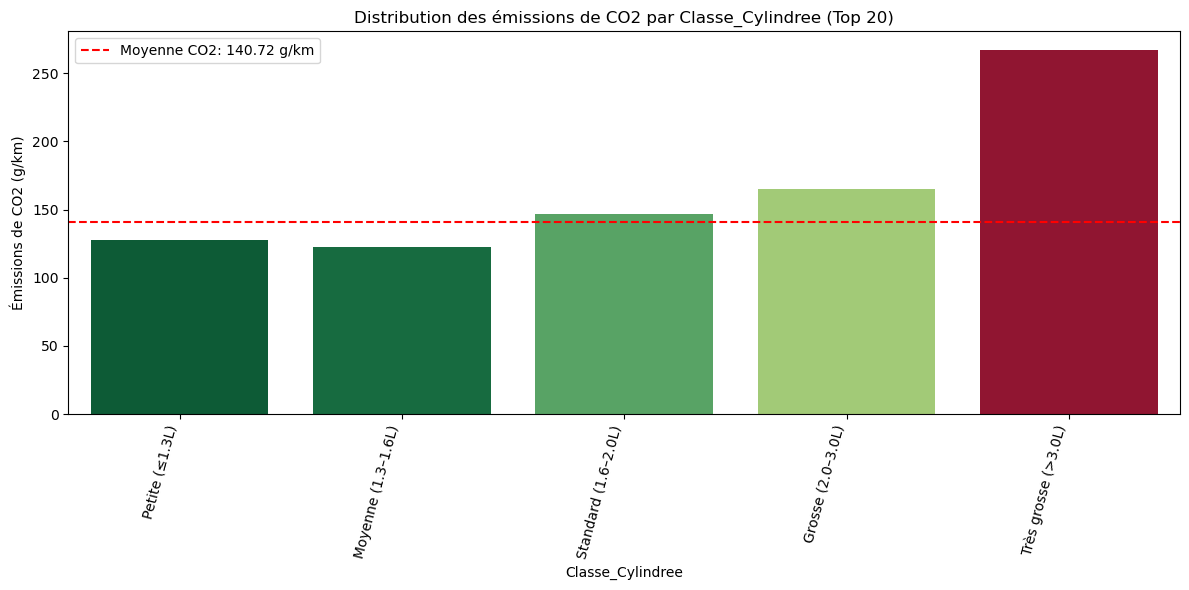

In [76]:
analyser_hist_co2_par_variable(df, 'Classe_Cylindree', 20, order='asc')

Plus la cylindrée **augmente**, plus les émissions de CO2 **augmentent**.

On passe d’environ **125 g/km** pour les petites cylindrées à plus de **270 g/km** pour les très grosses.

# <font color='#3585CD'>Corrélation des variables numériques</font>

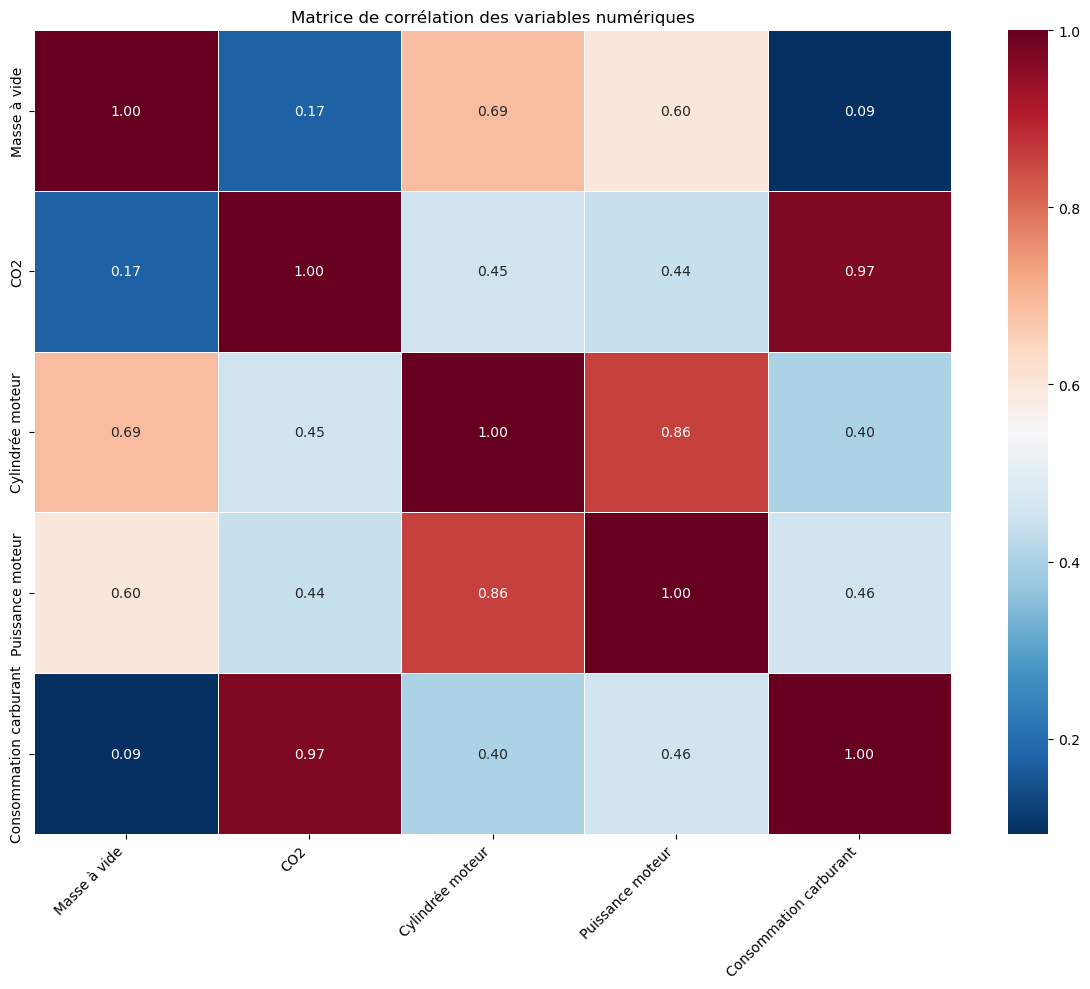

In [77]:
variables_selectionnees = ['Masse à vide', 'CO2', 'Cylindrée moteur', 'Puissance moteur', 'Consommation carburant']
plot_correlation_matrix(df[variables_selectionnees])

Nous observons : 
* une **très forte** corrélation entre la consommation de carburant et le CO2.
* une corrélation **modérée** entre la cylindrée et le CO2
* une corrélation **modérée** entre la puissance et le CO2
* une corrélation **faible** entre le poids et le CO2

# <font color='#3585CD'>Analyse des outliers</font>

## Masse à vide

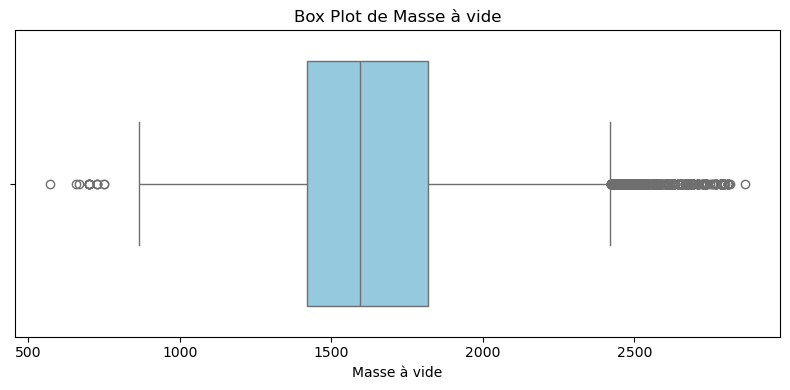

,Nb_Outliers,Pourcentage
Masse à vide,800,3.34


In [78]:
detecter_outliers(df['Masse à vide'])

Nous voyons la présence d’outliers de part et d’autre :

* Les plus légers : probablement des citadines
* Les plus lourds : SUV, hybrides rechargeables, utilitaires

Nous pouvons vérfier si ce sont seulement des valeurs **extrêmes** ou des valeurs **aberrantes**, auquel cas il faudra les traiter.

In [79]:
df_outliers_masse = df[df['Masse à vide'] < 750].sort_values(by='Masse à vide', ascending=True)
df_outliers_masse.head(20)

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant,Classe_Cylindree,Classe_Puissance,ICSM,ICE,IDEC,ICS
2976,CATERHAM,SEVEN S3,570.0,109,essence,658.0,62.0,4.8,Petite (≤1.3L),Faible (<110 ch),0.108772,0.094225,1.154386,12.916667
5150,SECMA,FUN 1600,658.0,142,essence,1598.0,77.0,6.3,Moyenne (1.3–1.6L),Faible (<110 ch),0.117021,0.048185,2.428571,12.222222
5151,SECMA,FUN 1600 BUGGY,668.0,142,essence,1598.0,77.0,6.3,Moyenne (1.3–1.6L),Faible (<110 ch),0.115269,0.048185,2.392216,12.222222
2977,CATERHAM,SEVEN S3,700.0,191,essence,1999.0,176.0,6.4,Standard (1.6–2.0L),Performante (150–199 ch),0.251429,0.088044,2.855714,27.500000
2978,CATERHAM,SEVEN S3,700.0,145,essence,1596.0,100.0,6.4,Moyenne (1.3–1.6L),Faible (<110 ch),0.142857,0.062657,2.280000,15.625000
2979,CATERHAM,SEVEN S3,700.0,145,essence,1596.0,100.0,8.5,Moyenne (1.3–1.6L),Faible (<110 ch),0.142857,0.062657,2.280000,11.764706
2980,CATERHAM,SEVEN S3,700.0,145,essence,1596.0,100.0,8.3,Moyenne (1.3–1.6L),Faible (<110 ch),0.142857,0.062657,2.280000,12.048193
2981,CATERHAM,SEVEN SV,700.0,191,essence,1999.0,176.0,6.4,Standard (1.6–2.0L),Performante (150–199 ch),0.251429,0.088044,2.855714,27.500000
2983,CATERHAM,SEVEN SV,700.0,145,essence,1596.0,100.0,8.5,Moyenne (1.3–1.6L),Faible (<110 ch),0.142857,0.062657,2.280000,11.764706
15692,CATERHAM,SEVEN S3,700.0,148,essence,1999.0,127.0,6.7,Standard (1.6–2.0L),Moyenne (110–149 ch),0.181429,0.063532,2.855714,18.955224


In [80]:
df_outliers_masse = df[df['Masse à vide'] > 2500].sort_values(by='Masse à vide', ascending=True)
df_outliers_masse.tail(20)

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant,Classe_Cylindree,Classe_Puissance,ICSM,ICE,IDEC,ICS
17346,BMW,XM LABEL,2795.0,45,hybride,4395.0,430.0,2.0,Très grosse (>3.0L),Très élevée (≥300 ch),0.153846,0.097838,1.572451,215.000000
22757,BMW,XM LABEL,2795.0,39,hybride,4395.0,430.0,1.7,Très grosse (>3.0L),Très élevée (≥300 ch),0.153846,0.097838,1.572451,252.941176
23315,BMW,XM LABEL,2795.0,42,hybride,4395.0,430.0,1.8,Très grosse (>3.0L),Très élevée (≥300 ch),0.153846,0.097838,1.572451,238.888889
20019,BMW,XM LABEL,2795.0,38,hybride,4395.0,430.0,1.7,Très grosse (>3.0L),Très élevée (≥300 ch),0.153846,0.097838,1.572451,252.941176
22100,BMW,XM LABEL,2795.0,44,hybride,4395.0,430.0,2.0,Très grosse (>3.0L),Très élevée (≥300 ch),0.153846,0.097838,1.572451,215.000000
20512,LAND ROVER,RANGE ROVER,2800.0,270,essence,4395.0,452.0,11.9,Très grosse (>3.0L),Très élevée (≥300 ch),0.161429,0.102844,1.569643,37.983193
2788,LAND ROVER,RANGE ROVER,2810.0,20,hybride,2996.0,294.0,0.9,Grosse (2.0–3.0L),Élevée (200–299 ch),0.104626,0.098131,1.066192,326.666667
2593,LAND ROVER,RANGE ROVER SPORT,2810.0,19,hybride,2996.0,294.0,0.9,Grosse (2.0–3.0L),Élevée (200–299 ch),0.104626,0.098131,1.066192,326.666667
2592,LAND ROVER,RANGE ROVER SPORT,2810.0,20,hybride,2996.0,294.0,0.9,Grosse (2.0–3.0L),Élevée (200–299 ch),0.104626,0.098131,1.066192,326.666667
15345,LAND ROVER,RANGE ROVER SPORT,2810.0,18,hybride,2996.0,294.0,0.8,Grosse (2.0–3.0L),Élevée (200–299 ch),0.104626,0.098131,1.066192,367.500000


Après analyse, ces valeurs ne sont pas aberrantes. Elles sont juste extrêmes. Nous décidons de les garder car elles sont représentatives de certains véhicules.

## Cylindrée moteur

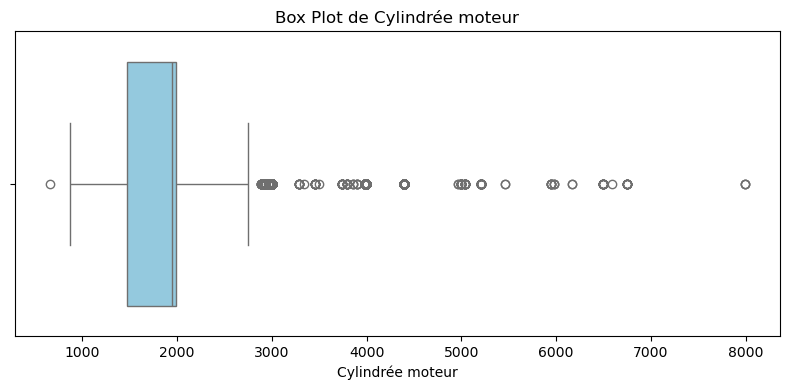

,Nb_Outliers,Pourcentage
Cylindrée moteur,2616,10.93


In [81]:
detecter_outliers(df['Cylindrée moteur'])

Il y a beaucoup d'outliers à droite (> 2800 cm³), dont un à 8000 cm³. Ce sont sans doute des véhicules de sport ou luxe.

Un outlier est siuté à gauche.

Nous pouvons vérfier si ce sont seulement des valeurs **extrêmes** ou des valeurs **aberrantes**, auquel cas il faudra les traiter.

In [82]:
df_outliers_CO2 = df[df['Cylindrée moteur'] > 4000].sort_values(by='Cylindrée moteur', ascending=True)
df_outliers_CO2.tail(20)

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant,Classe_Cylindree,Classe_Puissance,ICSM,ICE,IDEC,ICS
14501,FERRARI,812 COMPETIZIONE,1740.0,385,essence,6496.0,607.0,16.9,Très grosse (>3.0L),Très élevée (≥300 ch),0.348851,0.093442,3.733333,35.917160
14507,FERRARI,MONZA SP2,1706.0,366,essence,6496.0,592.0,16.1,Très grosse (>3.0L),Très élevée (≥300 ch),0.347011,0.091133,3.807737,36.770186
14522,LAMBORGHINI,AVENTADOR,1740.0,442,essence,6498.0,574.0,18.0,Très grosse (>3.0L),Très élevée (≥300 ch),0.329885,0.088335,3.734483,31.888889
14527,LAMBORGHINI,AVENTADOR,1790.0,442,essence,6498.0,574.0,18.0,Très grosse (>3.0L),Très élevée (≥300 ch),0.320670,0.088335,3.630168,31.888889
14521,LAMBORGHINI,AVENTADOR,1715.0,448,essence,6498.0,566.0,18.0,Très grosse (>3.0L),Très élevée (≥300 ch),0.330029,0.087104,3.788921,31.444444
14517,LAMBORGHINI,AVENTADOR,1780.0,440,essence,6498.0,574.0,19.5,Très grosse (>3.0L),Très élevée (≥300 ch),0.322472,0.088335,3.650562,29.435897
14516,LAMBORGHINI,AVENTADOR (COUNTACH),1780.0,440,essence,6498.0,574.0,19.5,Très grosse (>3.0L),Très élevée (≥300 ch),0.322472,0.088335,3.650562,29.435897
2947,ROLLS-ROYCE,Dawn,2705.0,368,essence,6592.0,441.0,16.2,Très grosse (>3.0L),Très élevée (≥300 ch),0.163031,0.066899,2.436969,27.222222
22118,ROLLS-ROYCE,GHOST EWB,2605.0,357,essence,6749.0,420.0,15.7,Très grosse (>3.0L),Très élevée (≥300 ch),0.161228,0.062231,2.590787,26.751592
2943,ROLLS-ROYCE,Ghost,2565.0,356,essence,6749.0,420.0,15.6,Très grosse (>3.0L),Très élevée (≥300 ch),0.163743,0.062231,2.631189,26.923077


Après analyse, ces valeurs ne sont pas aberrantes. Elles sont juste extrêmes. Nous décidons de les garder car elles sont représentatives de certains véhicules.

## CO2

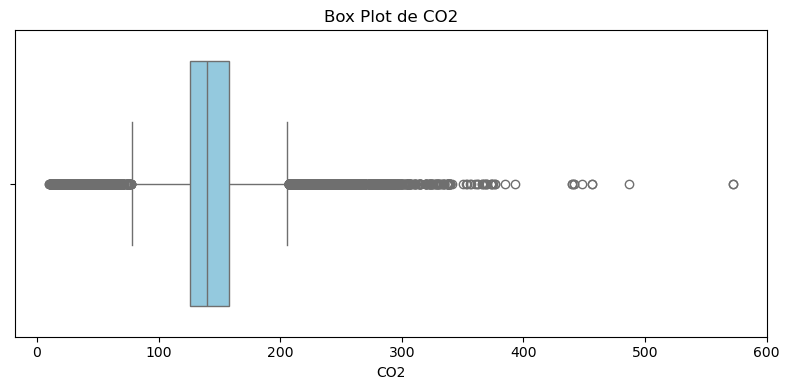

,Nb_Outliers,Pourcentage
CO2,3895,16.27


In [83]:
detecter_outliers(df['CO2'])

La distribution est **asymétrique** à droite : il y a une longue traîne. Cela signifie que quelques véhicules émettent beaucoup plus de CO2 que la majorité.

Nous pouvons vérfier si ce sont seulement des valeurs **extrêmes** ou des valeurs **aberrantes**, auquel cas il faudra les traiter.


In [84]:
df_outliers_CO2 = df[df['CO2'] > 400].sort_values(by='CO2', ascending=True)
df_outliers_CO2.tail(20)

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant,Classe_Cylindree,Classe_Puissance,ICSM,ICE,IDEC,ICS
14516,LAMBORGHINI,AVENTADOR (COUNTACH),1780.0,440,essence,6498.0,574.0,19.5,Très grosse (>3.0L),Très élevée (≥300 ch),0.322472,0.088335,3.650562,29.435897
14517,LAMBORGHINI,AVENTADOR,1780.0,440,essence,6498.0,574.0,19.5,Très grosse (>3.0L),Très élevée (≥300 ch),0.322472,0.088335,3.650562,29.435897
14522,LAMBORGHINI,AVENTADOR,1740.0,442,essence,6498.0,574.0,18.0,Très grosse (>3.0L),Très élevée (≥300 ch),0.329885,0.088335,3.734483,31.888889
14527,LAMBORGHINI,AVENTADOR,1790.0,442,essence,6498.0,574.0,18.0,Très grosse (>3.0L),Très élevée (≥300 ch),0.320670,0.088335,3.630168,31.888889
14521,LAMBORGHINI,AVENTADOR,1715.0,448,essence,6498.0,566.0,18.0,Très grosse (>3.0L),Très élevée (≥300 ch),0.330029,0.087104,3.788921,31.444444
11578,MERCEDES BENZ,AMG G 63 4X42,2866.0,456,essence,3982.0,430.0,20.1,Très grosse (>3.0L),Très élevée (≥300 ch),0.150035,0.107986,1.389393,21.393035
19997,MERCEDES BENZ,AMG G 63 4X42,2595.0,456,essence,3982.0,430.0,20.1,Très grosse (>3.0L),Très élevée (≥300 ch),0.165703,0.107986,1.534489,21.393035
20717,BUGATTI,BUGATTI CHIRON SUPER SPORT,2070.0,487,essence,7993.0,1177.0,21.5,Très grosse (>3.0L),Très élevée (≥300 ch),0.568599,0.147254,3.861353,54.744186
5128,BUGATTI,BUGATTI CHIRON PUR SPORT,2070.0,572,essence,7993.0,1103.0,25.2,Très grosse (>3.0L),Très élevée (≥300 ch),0.532850,0.137996,3.861353,43.769841
5129,BUGATTI,BUGATTI CHIRON,2070.0,572,essence,7993.0,1103.0,25.2,Très grosse (>3.0L),Très élevée (≥300 ch),0.532850,0.137996,3.861353,43.769841


Après analyse, ces valeurs ne sont pas aberrantes. Elles sont juste extrêmes. Nous décidons de les garder car elles sont représentatives de certains véhicules.

## Puissance moteur

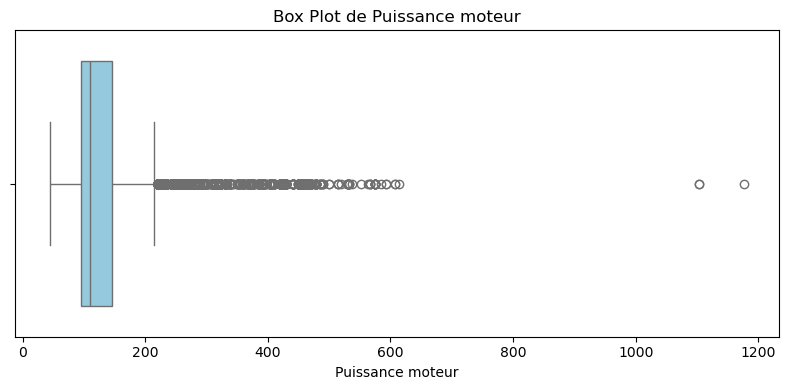

,Nb_Outliers,Pourcentage
Puissance moteur,2575,10.76


In [85]:
detecter_outliers(df['Puissance moteur'])

La **majorité** des véhicules ont entre 90 et 180 chevaux.

Beaucoup d’outliers sont **observés à droite**, représentant sans doute les véhicules puissants (sportives, gros SUV, ...)

2 véhicules sont particulièrement **extrêmes** (> 1000 ch).

Nous pouvons vérfier si ce sont seulement des valeurs **extrêmes** ou des valeurs **aberrantes**, auquel cas il faudra les traiter.


In [86]:
df_outliers_Consommation = df[df['Puissance moteur'] > 15].sort_values(by='Puissance moteur', ascending=True)
df_outliers_Consommation.tail(20)

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant,Classe_Cylindree,Classe_Puissance,ICSM,ICE,IDEC,ICS
14521,LAMBORGHINI,AVENTADOR,1715.0,448,essence,6498.0,566.0,18.0,Très grosse (>3.0L),Très élevée (≥300 ch),0.330029,0.087104,3.788921,31.444444
17722,ASTON MARTIN,DBS 770 ULTIMATE,2020.0,314,essence,5204.0,566.0,13.9,Très grosse (>3.0L),Très élevée (≥300 ch),0.280198,0.108762,2.576238,40.719424
19122,ASTON MARTIN,DBS 770 ULTIMATE VOLANTE,2020.0,314,essence,5204.0,566.0,13.9,Très grosse (>3.0L),Très élevée (≥300 ch),0.280198,0.108762,2.576238,40.719424
14522,LAMBORGHINI,AVENTADOR,1740.0,442,essence,6498.0,574.0,18.0,Très grosse (>3.0L),Très élevée (≥300 ch),0.329885,0.088335,3.734483,31.888889
14508,FERRARI,SF90 STRADALE,1820.0,160,hybride,3990.0,574.0,6.0,Très grosse (>3.0L),Très élevée (≥300 ch),0.315385,0.143860,2.192308,95.666667
14527,LAMBORGHINI,AVENTADOR,1790.0,442,essence,6498.0,574.0,18.0,Très grosse (>3.0L),Très élevée (≥300 ch),0.320670,0.088335,3.630168,31.888889
14509,FERRARI,SF90 STRADALE,1850.0,154,hybride,3990.0,574.0,6.1,Très grosse (>3.0L),Très élevée (≥300 ch),0.310270,0.143860,2.156757,94.098361
14517,LAMBORGHINI,AVENTADOR,1780.0,440,essence,6498.0,574.0,19.5,Très grosse (>3.0L),Très élevée (≥300 ch),0.322472,0.088335,3.650562,29.435897
14510,FERRARI,SF90 SPIDER,1925.0,149,hybride,3990.0,574.0,6.1,Très grosse (>3.0L),Très élevée (≥300 ch),0.298182,0.143860,2.072727,94.098361
14516,LAMBORGHINI,AVENTADOR (COUNTACH),1780.0,440,essence,6498.0,574.0,19.5,Très grosse (>3.0L),Très élevée (≥300 ch),0.322472,0.088335,3.650562,29.435897


Après analyse, ces valeurs ne sont pas aberrantes. Elles sont juste extrêmes. Nous décidons de les garder car elles sont représentatives de certains véhicules.

## Consommation carburant

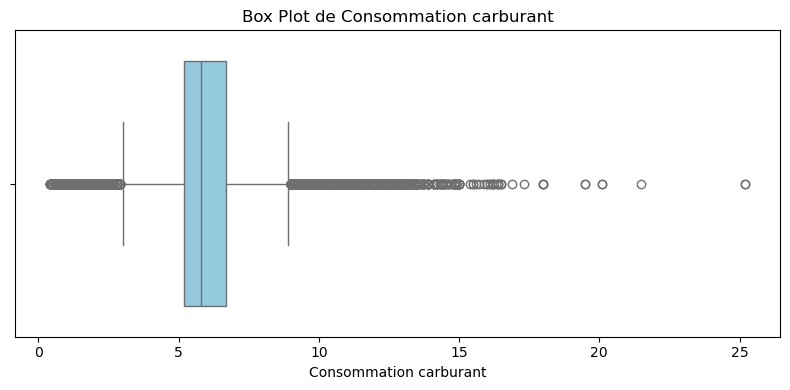

,Nb_Outliers,Pourcentage
Consommation carburant,3410,14.25


In [87]:
detecter_outliers(df['Consommation carburant'])

 Nous obervons une **longue traîne à droite** : ces véhicules sont très énergivores.

Les extrêmes > 15 L/100 km sont très rares mais à surveiller.

Nous pouvons vérfier si ce sont seulement des valeurs **extrêmes** ou des valeurs **aberrantes**, auquel cas il faudra les traiter.


In [88]:
df_outliers_Consommation = df[df['Consommation carburant'] > 15].sort_values(by='Consommation carburant', ascending=True)
df_outliers_Consommation.tail(20)

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant,Classe_Cylindree,Classe_Puissance,ICSM,ICE,IDEC,ICS
18575,FERRARI,FERRARI DAYTONA SP3,1705.0,368,essence,6496.0,614.0,16.2,Très grosse (>3.0L),Très élevée (≥300 ch),0.360117,0.094520,3.809971,37.901235
19565,FERRARI,812 COMPETIZIONE A,1810.0,370,essence,6496.0,607.0,16.3,Très grosse (>3.0L),Très élevée (≥300 ch),0.335359,0.093442,3.588950,37.239264
2946,ROLLS-ROYCE,Cullinan Black Badge,2785.0,374,essence,6749.0,441.0,16.4,Très grosse (>3.0L),Très élevée (≥300 ch),0.158348,0.065343,2.423339,26.890244
14512,FERRARI,812 GTS,1865.0,373,essence,6496.0,585.0,16.4,Très grosse (>3.0L),Très élevée (≥300 ch),0.313673,0.090055,3.483110,35.670732
11576,MERCEDES BENZ,AMG G 63,2560.0,373,essence,3982.0,430.0,16.4,Très grosse (>3.0L),Très élevée (≥300 ch),0.167969,0.107986,1.555469,26.219512
16543,CHEVROLET,CORVETTE,1833.0,377,essence,5460.0,475.0,16.5,Très grosse (>3.0L),Très élevée (≥300 ch),0.259138,0.086996,2.978723,28.787879
22704,ROLLS-ROYCE,CULLINAN BLACK BADGE,2785.0,375,essence,6749.0,441.0,16.5,Très grosse (>3.0L),Très élevée (≥300 ch),0.158348,0.065343,2.423339,26.727273
23418,CHEVROLET,CORVETTE,1789.0,377,essence,5460.0,475.0,16.5,Très grosse (>3.0L),Très élevée (≥300 ch),0.265511,0.086996,3.051984,28.787879
14501,FERRARI,812 COMPETIZIONE,1740.0,385,essence,6496.0,607.0,16.9,Très grosse (>3.0L),Très élevée (≥300 ch),0.348851,0.093442,3.733333,35.917160
17392,FERRARI,FERRARI PUROSANGUE,2245.0,393,essence,6496.0,529.0,17.3,Très grosse (>3.0L),Très élevée (≥300 ch),0.235635,0.081435,2.893541,30.578035


Après analyse, ces valeurs ne sont pas aberrantes. Elles sont juste extrêmes. Nous décidons de les garder car elles sont représentatives de certains véhicules.

# <font color='#3585CD'>Visualisation globale graphique</font>

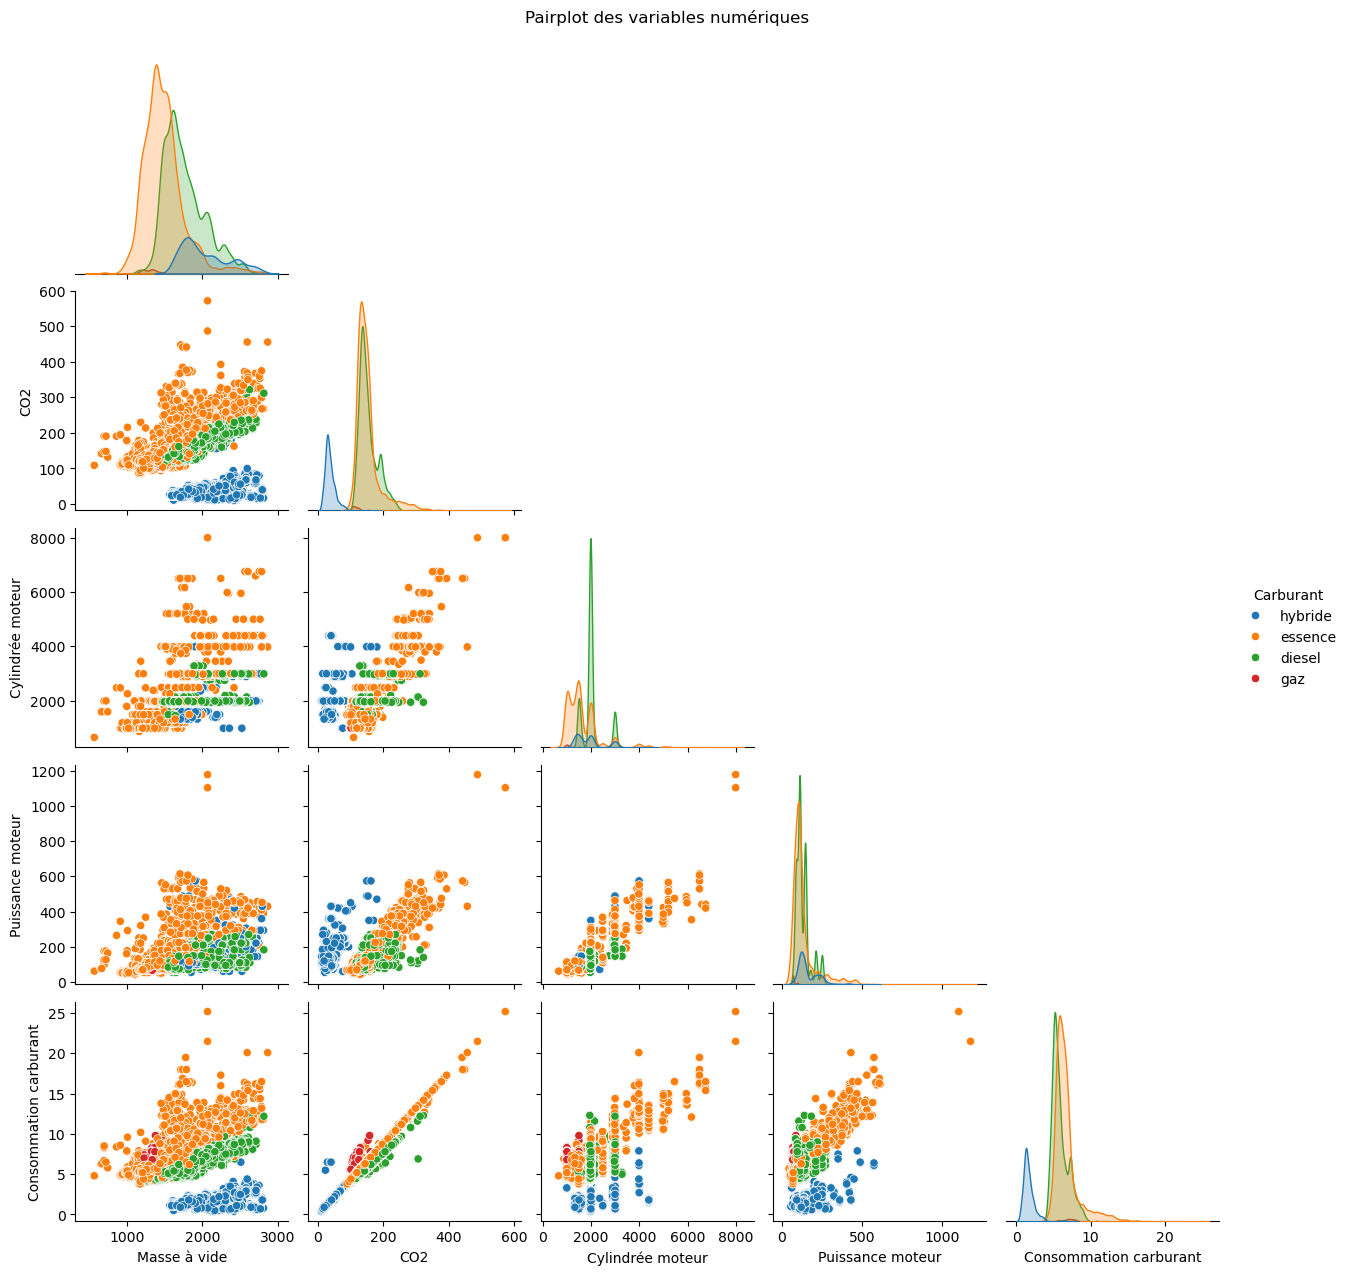

In [89]:
#numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
numeric_cols = ['Masse à vide', 'CO2', 'Cylindrée moteur', 'Puissance moteur', 'Consommation carburant']

hue_var = 'Carburant'
if visualisation == 'plotly': 
    fig = px.scatter_matrix(df, dimensions=df.select_dtypes(include=['number']).columns,
                            color='Carburant', title="Pairplot des variables numériques")

    fig.update_layout(height=900, width=1200)
    fig.show()
elif visualisation == 'seaborn':
    # Pairplot Seaborn
    sns.pairplot(df[numeric_cols + [hue_var]], hue=hue_var, corner=True)
    plt.suptitle("Pairplot des variables numériques", y=1.02)
    plt.show()

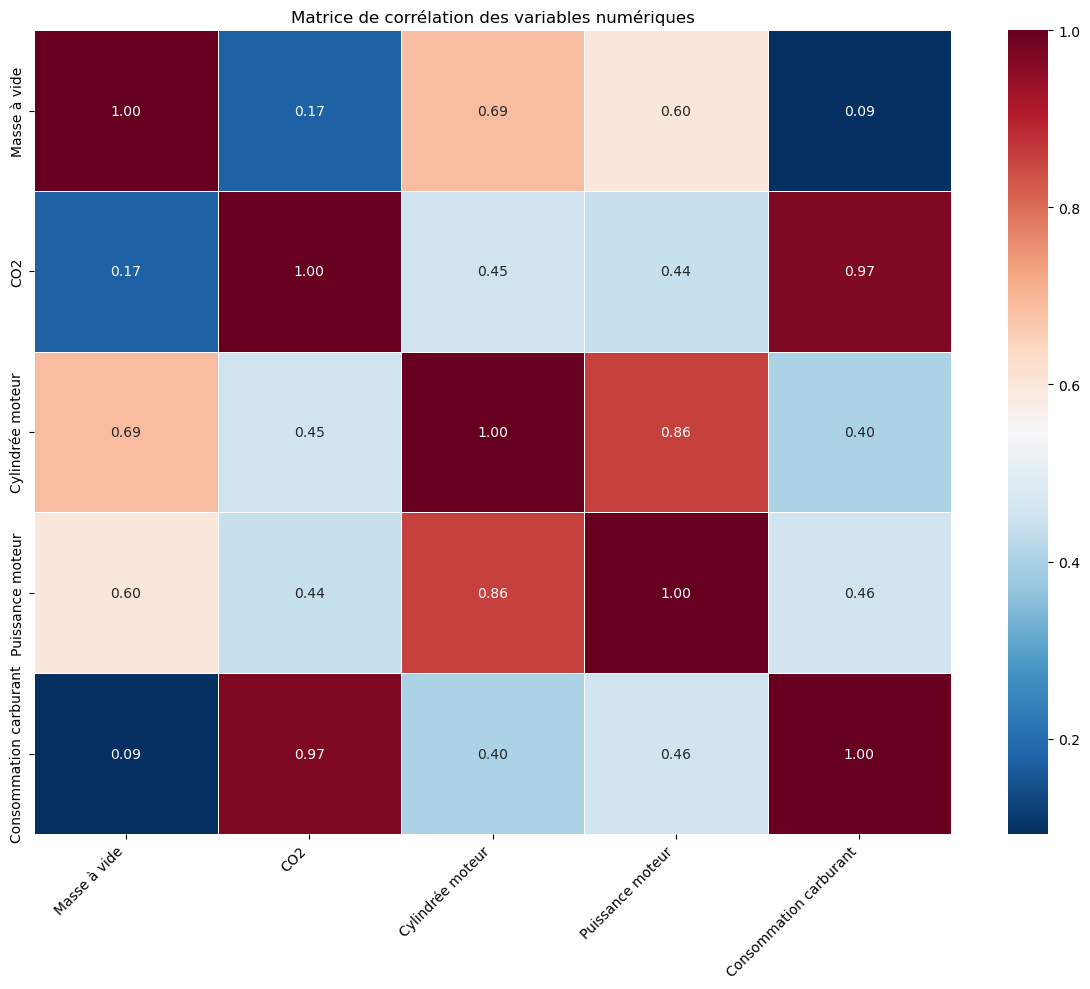

In [90]:
plot_correlation_matrix(df[numeric_cols])

# <font color='#3585CD'>Quelles variables garder pour prédire le CO2 ?</font>

Dans un premier temps, nous garderons les variables ci-dessous pour commencer la modélisation :
* **Masse à vide** : un véhicule plus lourd a souvent des émissions plus élevées.
* **Cylindrée moteur** : une plus grande cylindrée est souvent associée à une plus grande consommation et donc plus d’émissions.
* **Puissance moteur** : un moteur plus puissant a tendance à consommer plus de carburant.
* **Carburant** : Essence, diesel, hybride… Chaque type influence les émissions. La variable Carburant sera encodée.

* **Consommation carburant** : directement liée aux émissions de CO2. Cependant sa forte corrélation peut expliquer à elle seule les émissions de CO2. Nous nous questionnerons au moment de la modélisation si nous la gardons ou pas.

Nous **excluerons** les variables **Marque** et **Modèle** qui ne sont pas directement liées aux émissions de CO2.

Pourquoi exclure les variables **Marque** et **Modèle** ?
* Ce sont des variables catégoriques à très haute **cardinalité**
* L'influence sur le CO₂ passe par des **caractéristiques techniques**

Après la mise en place des premiers modèles, nous reviendrons éventuellement sur notre dataset pour analyser la combinaison sur d'autres variables.

# <font color='#3585CD'>Export du dataset final</font>

Nous vérifions une dernière fois si des doublons sont présents :

In [ ]:
df.duplicated().sum()

40

In [100]:
df = df.drop_duplicates()

In [101]:
df.duplicated().sum()

0

In [106]:
df = df.reset_index(drop=True)

In [107]:
df

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant,Classe_Cylindree,Classe_Puissance,ICSM,ICE,IDEC,ICS
0,JEEP,RENEGADE,1845.0,49,hybride,1332.0,96.0,2.0,Moyenne (1.3–1.6L),Faible (<110 ch),0.052033,0.072072,0.721951,48.000000
1,JEEP,WRANGLER,1883.0,244,essence,1995.0,200.0,10.8,Standard (1.6–2.0L),Élevée (200–299 ch),0.106213,0.100251,1.059480,18.518519
2,JEEP,WRANGLER,1972.0,259,essence,1995.0,200.0,11.5,Standard (1.6–2.0L),Élevée (200–299 ch),0.101420,0.100251,1.011663,17.391304
3,JEEP,WRANGLER,1972.0,258,essence,1995.0,200.0,11.5,Standard (1.6–2.0L),Élevée (200–299 ch),0.101420,0.100251,1.011663,17.391304
4,JEEP,WRANGLER UNLIMITED,2348.0,79,hybride,1995.0,200.0,3.5,Standard (1.6–2.0L),Élevée (200–299 ch),0.085179,0.100251,0.849659,57.142857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23890,SKODA,SCALA,1211.0,119,essence,999.0,70.0,5.2,Petite (≤1.3L),Faible (<110 ch),0.057803,0.070070,0.824938,13.461538
23891,FORD,TRANSIT CUSTOM,2311.0,197,diesel,1995.0,95.0,7.5,Standard (1.6–2.0L),Faible (<110 ch),0.041108,0.047619,0.863263,12.666667
23892,MERCEDES BENZ,A 200,1440.0,144,essence,1332.0,120.0,6.3,Moyenne (1.3–1.6L),Moyenne (110–149 ch),0.083333,0.090090,0.925000,19.047619
23893,MERCEDES BENZ,V-KLASSE,2220.0,225,diesel,1950.0,174.0,8.6,Standard (1.6–2.0L),Performante (150–199 ch),0.078378,0.089231,0.878378,20.232558


In [108]:
df_final = df.drop(['Classe_Cylindree', 'Classe_Puissance', 'ICSM', 'ICE', 'IDEC', 'ICS'], axis=1)
df_final

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant
0,JEEP,RENEGADE,1845.0,49,hybride,1332.0,96.0,2.0
1,JEEP,WRANGLER,1883.0,244,essence,1995.0,200.0,10.8
2,JEEP,WRANGLER,1972.0,259,essence,1995.0,200.0,11.5
3,JEEP,WRANGLER,1972.0,258,essence,1995.0,200.0,11.5
4,JEEP,WRANGLER UNLIMITED,2348.0,79,hybride,1995.0,200.0,3.5
...,...,...,...,...,...,...,...,...
23890,SKODA,SCALA,1211.0,119,essence,999.0,70.0,5.2
23891,FORD,TRANSIT CUSTOM,2311.0,197,diesel,1995.0,95.0,7.5
23892,MERCEDES BENZ,A 200,1440.0,144,essence,1332.0,120.0,6.3
23893,MERCEDES BENZ,V-KLASSE,2220.0,225,diesel,1950.0,174.0,8.6


In [109]:
print(f"Notre dataset final est composé de {df_final.shape[0]} lignes")

Notre dataset final est composé de 23895 lignes


In [110]:
# Vérifier si on est sur Google Colab
import os
try:
    import google.colab
    ON_COLAB = True
    dataset_path = "/content/drive/My Drive/Formation DS/Projet CO2/NOV24-CDS-CO2/notebooks/datasets/Dataset_final/datas_nettoyees_model_FR.csv"

    # Monter Google Drive si ce n'est pas déjà fait
    from google.colab import drive
    drive.mount('/content/drive')

except ImportError:
    ON_COLAB = False
    dataset_path = "datasets/Dataset_final/datas_nettoyees_model_FR.csv"

# Sauvegarde du DataFrame
df_final.to_csv(dataset_path, index=False)

# Vérification de l'enregistrement
if os.path.exists(dataset_path):
    print(f"Le fichier a bien été enregistré à l'emplacement : {dataset_path}")
else:
    print("Problème lors de l'enregistrement du fichier.")


Le fichier a bien été enregistré à l'emplacement : datasets/Dataset_final/datas_nettoyees_model_FR.csv
